# <a id='toc1_'></a>[Multi-Perspective Segmentation Project](#toc0_)

## <a id='toc1_1_'></a>[Data Mining Project](#toc0_)
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689
- Veronica Mendes 20221945

----

## <a id='toc1_2_'></a>[Summary](#toc0_)

This notebook combines **Value-based**, **Demographic** and **Behavioral** perspectives to create a unified customer segmentation.


**Table of contents**<a id='toc0_'></a>      
  - [Imports](#toc1_3_)    
  - [Load Data](#toc1_4_)    
  - [ Merge Perspectives](#toc1_5_)    
  - [Outliers](#toc1_6_)    
  - [Missing Values](#toc1_7_)    
  - [Scaling](#toc1_8_)    
  - [Autoencoder](#toc1_9_)    
  - [Hierarchical](#toc1_10_)    
  - [K-Means](#toc1_11_)    
  - [C-Means](#toc1_12_)    
  - [Conclusion](#toc1_13_)    
  - [Final Cluster](#toc1_14_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_3_'></a>[Imports](#toc0_)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import umap
import warnings

from sklearn.preprocessing import  MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score
import skfuzzy as fuzz

from matplotlib.lines import Line2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## <a id='toc1_4_'></a>[Load Data](#toc0_)

First, we need to load the datasets for each perspective.

In [2]:
demographic = pd.read_csv('demographic_clusters.csv')
behavioral = pd.read_csv('behavioral_clusters_year.csv')
behavioral_m = pd.read_csv('behavioral_clusters_month.csv')
value_based = pd.read_csv('value_based_clusters.csv')

df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

Let's look at the cluster distribution in each perspective.

In [3]:
print(demographic['Demographic_Cluster_Name'].nunique())
print(behavioral['Behavioral_Year_Cluster_Name'].nunique())
print(behavioral_m['Behavioral_Month_Cluster_Name'].nunique())
print(value_based['Value_Based_Cluster_Name'].nunique())

4
9
15
9


The Demographic perspective contains 4 clusters, Value-Based has 9, Behavioral (Yearly) has 9, and Behavioral (Monthly) with 15 clusters. If we were to consider every possible intersection of these segments, it would result in approximately 4,860 unique combinations.

## <a id='toc1_5_'></a>[ Merge Perspectives](#toc0_)
We join the perspectives using a common identifier (Loyalty#).

In [4]:
df_multi_perspective = (df_AIAI_Master_Complete
             .merge(demographic, on='Loyalty#', how='inner')
             .merge(behavioral, on='Loyalty#', how='inner')
             .merge(behavioral_m, on='Loyalty#', how='inner')
             .merge(value_based, on='Loyalty#', how='inner')).copy()
df_multi_perspective.head()

,Loyalty#,First Name,Last Name,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Re_engaged_people,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name
0,480934,Cecilia,Householder,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,False,1049,NaN,191.0,497375.0,29.319372,362.1394,29.0,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\r\n(Loyal),Avr|Mar Companion\n(Less travel on mar),Fly fanatics
1,549612,Dayle,Menez,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard,False,1027,NaN,279.0,389939.0,11.469534,165.2639,29.0,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500,Low-Income West,Formers Points accumulator\r\n(2020),Avr|Point Acumulator\n(No companions),Fly fanatics
2,429460,Necole,Hannon,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0

In [5]:
df_multi_perspective.set_index('Loyalty#', inplace=True)

In [6]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 90 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   First Name                             16572 non-null  object        
 1   Last Name                              16572 non-null  object        
 2   Customer Name                          16572 non-null  object        
 3   Province or State                      16572 non-null  object        
 4   City                                   16572 non-null  object        
 5   Latitude                               16572 non-null  float64       
 6   Longitude                              16572 non-null  float64       
 7   Postal code                            16572 non-null  object        
 8   Gender                                 16572 non-null  object        
 9   Education                              16572 non-null  objec

We are going to remove this columns from the dataset, because they are not to be used, since some of them are not important for profiling or redundant.

In [7]:
# list of columns to remove
cols_to_remove = ['First Name', 'Last Name', 'Customer Name', 'Postal code',
                  'EnrollmentDateOpening', 'CancellationDate', 'EnrollmentType','Re_engaged_people',
                  'Total_NumFlights_2019', 'Total_DistanceKM_2019', 'Perc_Flights_With_Companions_2019',
                  'Dollar_Cost_Points_Remaining_2019',]

# Drop them
df_multi_perspective.drop(inplace=True,columns=cols_to_remove)

In [8]:
df_multi_perspective.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 78 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Province or State                      16572 non-null  object 
 1   City                                   16572 non-null  object 
 2   Latitude                               16572 non-null  float64
 3   Longitude                              16572 non-null  float64
 4   Gender                                 16572 non-null  object 
 5   Education                              16572 non-null  object 
 6   Location Code                          16572 non-null  object 
 7   Income                                 16572 non-null  float64
 8   Marital Status                         16572 non-null  object 
 9   LoyaltyStatus                          16572 non-null  object 
 10  Customer Lifetime Value                16572 non-null  float64
 11  D

## <a id='toc1_6_'></a>[Outliers](#toc0_)

We will apply an outlier handling strategy using the Interquartile Range (IQR) method. Data points falling beyond 3 times the IQR (extreme outliers) will be capped for the variables previously proposed in each perspective.

In [9]:
columns_to_remove = ['Customer Lifetime Value',
                     'Dollar_Cost_Points_Remaining_month_1','Dollar_Cost_Points_Remaining_month_2',
                     'Dollar_Cost_Points_Remaining_month_3','Dollar_Cost_Points_Remaining_month_4',
                     'Dollar_Cost_Points_Remaining_month_5','Dollar_Cost_Points_Remaining_month_6',
                     'Dollar_Cost_Points_Remaining_month_7','Dollar_Cost_Points_Remaining_month_8',
                     'Dollar_Cost_Points_Remaining_month_9', 'Dollar_Cost_Points_Remaining_month_10',
                     'Dollar_Cost_Points_Remaining_month_11', 'Dollar_Cost_Points_Remaining_month_12']

for col in columns_to_remove:
   q1 = df_multi_perspective[col].quantile(0.25)
   q3 = df_multi_perspective[col].quantile(0.75)
   iqr = q3 - q1
   lower_extreme = q1 - 3 * iqr
   upper_extreme = q3 + 3 * iqr

   df_multi_perspective[col] = df_multi_perspective[col].clip(lower=lower_extreme, upper=upper_extreme)

We will apply a cap of 365 on Rencency.

In [10]:
df_multi_perspective['Recency_Days'] = df_multi_perspective['Recency_Days'].clip(upper=365)

We will apply a floor of 0 to 'Dollar Cost Points Remaining,' as it is impossible to utilize more points than the total amount allocated.

In [11]:
df_multi_perspective['Dollar_Cost_Points_Remaining'] = df_multi_perspective['Dollar_Cost_Points_Remaining'].clip(lower=0)

In [12]:
df_multi_perspective.head()

,Province or State,City,Latitude,Longitude,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,Urban,70146.0,Married,Star,3839.14,1049,NaN,191.0,497375.0,29.319372,362.1394,29.0,64.0,68.0,128976.0,252320.0,29.687500,29.411765,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\r\n(Loyal),Avr|Mar Companion\n(Less travel on mar),Fly fanatics
549612,Alberta,Edmonton,53.544388,-113.490930,male,College,Rural,0.0,Divorced,Star,3839.61,1027,NaN,279.0,389939.0,11.469534,165.2639,29.0,99.0,91.0,142191.0,119776.0,8.080808,18.681319,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-142.9017,76.7735,24.3200,33.6881,35.8801,27.1500,Low-Income West,Formers Points accumulator\r\n(2020),Avr|Point Acumulator\n(No companions),Fly fanatics
429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,Urban,0.0,Single,Star,3839.75,1274,NaN,120.0,229821.0,33.333333,174.9763,363.0,60.0,6.0,108547.0,23583.0,35.000000,0.000000,79.66,23.58,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764.0,6097.0,30356.0,0.0,6110.0,0.0,0.0,16881.0,56823.0,0.0,1030.0,45760.0,0.000000,75.000000,86.666667,0.000000,8.695652,0.000000,0.0,80.952381,0.000000,0.000000,0.000000,100.000000,66.7543,-48.7079,30.3493,0.000

## <a id='toc1_7_'></a>[Missing Values](#toc0_)

Certain missing values exhibit non-random behavior; specifically, they correspond to customers with no transaction history. We will treat these as structural zeros.

In [13]:
df_multi_perspective.isna().sum()

Province or State                           0
City                                        0
Latitude                                    0
Longitude                                   0
Gender                                      0
                                         ... 
Dollar_Cost_Points_Remaining_month_12    1471
Demographic_Cluster_Name                    0
Behavioral_Year_Cluster_Name                0
Behavioral_Month_Cluster_Name               0
Value_Based_Cluster_Name                    0
Length: 78, dtype: int64

In [14]:
df_multi_perspective.fillna(0, inplace=True)

## <a id='toc1_8_'></a>[Scaling](#toc0_)

We are going to scaled only the variables that we are going to use for modeling. We will use MinMaxScaler

In [15]:
columns_to_drop=['Province or State','City','Gender','Education','Location Code','Marital Status','LoyaltyStatus',
                 'Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name','Value_Based_Cluster_Name', 'Behavioral_Month_Cluster_Name']
df_for_modeling = df_multi_perspective.drop(columns_to_drop, axis=1)

In [16]:
df_for_modeling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 67 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Latitude                               16572 non-null  float64
 1   Longitude                              16572 non-null  float64
 2   Income                                 16572 non-null  float64
 3   Customer Lifetime Value                16572 non-null  float64
 4   Days_with_us                           16572 non-null  int64  
 5   Days_until_reengagement                16572 non-null  float64
 6   Total_NumFlights                       16572 non-null  float64
 7   Total_DistanceKM                       16572 non-null  float64
 8   Perc_Flights_With_Companions           16572 non-null  float64
 9   Dollar_Cost_Points_Remaining           16572 non-null  float64
 10  Recency_Days                           16572 non-null  float64
 11  T

In [17]:
scaler = MinMaxScaler(feature_range=(-1, 1))
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_for_modeling),
    index=df_for_modeling.index,
    columns=df_for_modeling.columns
)

In [18]:
df_for_modeling.head()

,Latitude,Longitude,Income,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,-0.924640,0.352217,0.403187,-0.823392,-0.148884,-1.0,0.094556,0.395690,-0.413613,0.110600,-0.841096,-0.058824,-0.014493,-0.101322,0.723197,-0.406250,-0.411765,0.226085,0.470458,-0.891892,-0.529412,-0.911111,-0.35,0.391304,-0.172414,-0.016393,0.192308,-0.227273,-0.609756,-0.210526,-0.632653,-0.315672,0.857947,-0.738060,-0.881069,0.451549,-0.241395,-0.173170,-0.168358,0.002735,0.712493,-0.450050,-0.117143,-1.000000,-0.500000,1.000000,-0.538462,-0.375000,-1.000000,-1.0,-0.290323,0.176471,0.000000,0.466667,-0.333333,0.362942,0.933138,0.186312,0.115698,0.743965,0.419770,0.463930,0.466234,0.542396,0.464049,-0.187678,0.047650
549612,0.190720,-0.476201,-1.000000,-0.823349,-0.166734,-1.0,0.598854,0.094212,-0.770609,-0.493173,-0.841096,0.455882,0.318841,-0.009243,-0.182000,-0.838384,-0.626374,0.084835,-0.191563,0.297297,0.000000,0.422222,-0.50,0.826087,-0.586207,0.180328,0.384615,-0.545455,0.365854,0.105263,-0.551020,-0.287835,-0.258960,-0.388021,-0.755308,0.216922,-0.946818,-0.335845,0.420826,-0.452429,-0.186522,-0.070931,-0.468064,-0.500000,-1.000000,-1.000000,-0.400000,-1.000000,-0.166667,-0.5,-0.500000,-1.000000,-1.000000,-1.000000,-1.000000,0.022980,0.404176,0.350153,0.174948,0.634326,0.090104,-1.000000,0.735342,0.333519,0.462776,0.516518,0.347975
429460,-0.289838,-0.710093,-1.000000,-0.823336,0.033671,-1.0,-0.312321,-0.355097,-0.333333,-0.463387,0.989041,-0.117647,-0.913043,-0.243667,-0.838942,-0.300000,-1.000000,0.105484,-0.184596,0.135135,-0.529412,-0.333333,-1.00,0.000000,-1.000000,-1.000000,-0.192308,-0.318182,-1.000000,-0.210526,-0.918367,0.814979,-0.827058,-0.354800,-1.000000,-0.871819,-1.000000,-1.000000,-0.687635,0.279120,-1.000000,-0.973336,-0.103448,-1.000000,0.500000,0.733333,-1.000000,-0.826087,-1.000000,-1.0,0.619048,-1.000000,-1.000000,-1.000000,1.000000,0.910469,-0.601283,0.365727,0.059578,0.125869,0.065304,0.086147,0.229050,0.669214,0.094675,0.109210,0.509886
608370,-0.924640,0.352217,-1.000000,-0.823336,0.738742,-1.0,0.123209,0.083243,-0.408163,-0.31721

This is going to be used to create the umap.

In [19]:
umap_for_modeling= df_for_modeling.copy()

We will use the centroids of the combinations of each indiviual perspective.

In [20]:
df_size = df_multi_perspective.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name',
                                        'Behavioral_Month_Cluster_Name', 'Value_Based_Cluster_Name']).size()
df_size

Demographic_Cluster_Name  Behavioral_Year_Cluster_Name              Behavioral_Month_Cluster_Name            Value_Based_Cluster_Name   
High-Income East          Consistent low travelers\r\n(Use points)  Avr|Dec Companion\n(Less travel on dec)  Fly fanatics                    3
                                                                                                             High-Value Frequent Flyers      3
                                                                                                             High-Value Low transactions     1
                                                                                                             Long-tenure                    21
                                                                                                             New engaged                    15
                                                                                                                                            ..
Low-I

We see that the combination of labels is less than 4860, meaning that the perspectives do not combine completely with each other.

In [21]:
df_for_modeling['Demographic_Cluster_Name']= df_multi_perspective['Demographic_Cluster_Name']
df_for_modeling['Behavioral_Year_Cluster_Name']= df_multi_perspective['Behavioral_Year_Cluster_Name']
df_for_modeling['Behavioral_Month_Cluster_Name']= df_multi_perspective['Behavioral_Month_Cluster_Name']
df_for_modeling['Value_Based_Cluster_Name']= df_multi_perspective['Value_Based_Cluster_Name']

In [22]:
df_centroids = df_for_modeling.groupby(['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name',
                                         'Behavioral_Month_Cluster_Name','Value_Based_Cluster_Name']).mean()
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                -0.800379   
                                                                                                          High-Value Frequent Flyers  -0.855160   
                                                                                                          High-Value Low transactions -0.924640   
                                                                                                          Long-tenure                 -0.815406   
                                                                                                          New engaged                 -0.784981   
...                                                                                                                                         ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                 -0.186616   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                -0.213367   
                                                                                                          High-Value Frequent Flyers  -0.086938   
                                                                                                          Long-tenure                 -0.186024   
                                                                                                          New engaged                 -0.220781   

                                                                                                                                       Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                 
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                  0.583344   
                                                                                                          High-Value Frequent Flyers    0.399303   
                                                                                                          High-Value Low transactions   0.352217   
                                                                                                          Long-tenure                   0.454108   
                                                                                                          New engaged                   0.456025   
...                                                                                                                                          ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                  -0.609297   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                 -0.643435   
                                                                                                          High-Value Frequent Flyers   -0.549443   
                                                                                                          Long-tenure                  -0.589795   
                                                                                                          New engaged                  -0.079026   

                                                                                                                                         Income  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High

## <a id='toc1_9_'></a>[Autoencoder](#toc0_)

Since we have 67 columns to apply clusters on, and the columns are very related to one another—for example, the entire month perspective can provide value-based general metrics—we decided to use an autoencoder to obtain a more compressed representation of the data. This allows us to reduce the number of dimensions and create unique, meaningful features.

In [23]:
# --- STEP 1:
np.random.seed(42)
n_archetypes = df_centroids.shape[0]
n_features = df_centroids.shape[1]

# Simulated Centroids (Normalized)
X = df_centroids
# weights importance of each centroid
weights = df_size / df_size.mean() # Normalize weights

We are going to try a very simple network architecture: one hidden layer of neurons with sizes [64, 48, 32] for both the encoder and decoder, and a code or bottleneck layer of [8, 16, 22, 32] neurons. We will analyze the results using k-fold cross-validation to see which architecture manages to compress the data as much as possible without losing too much information.

In [30]:
# --- STEP 2: Configuration ---
hidden_sizes = [64, 48, 32]
bottleneck_sizes = [8, 16, 22, 32]
n_folds = 5
epochs = 100  # Increased to allow Callbacks to manage the stop

# Storage
search_history = {}

# --- STEP 3: Grid Search Loop ---
print("--- Starting Grid Search ---")

for h_dim in hidden_sizes:
    for b_dim in bottleneck_sizes:
        config_id = f"H{h_dim}_B{b_dim}"
        print(f"Training Config: {config_id}...")

        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

        # Store curves for this specific config
        config_train_curves = []
        config_val_curves = []
        val_scores = []

        for train_ix, val_ix in kf.split(X):
            X_train, X_val = X.iloc[train_ix], X.iloc[val_ix]
            w_train, w_val = weights[train_ix], weights[val_ix]

            # --- DEFINE CALLBACKS (Fresh for every fold) ---
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=10,               # Stop if no improvement for 10 epochs
                    restore_best_weights=True, # Revert to the best epoch found
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.1,                # Cut LR
                    patience=4,                # If stuck for 5 epochs
                    min_lr=0.00001,            # Don't go below this
                    verbose=0
                )
            ]

            # Build Model
            input_layer = Input(shape=(n_features,))
            encoder_h = Dense(h_dim, activation="relu")(input_layer)
            bottleneck = Dense(b_dim, activation="relu")(encoder_h)
            decoder_h = Dense(h_dim, activation="relu")(bottleneck)
            output_layer = Dense(n_features, activation="linear")(decoder_h)

            autoencoder = Model(inputs=input_layer, outputs=output_layer)
            autoencoder.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

            history = autoencoder.fit(
                X_train, X_train,
                sample_weight=w_train,
                validation_data=(X_val, X_val, w_val),
                epochs=epochs,
                batch_size=32,
                callbacks=callbacks,
                verbose=0
            )

            config_train_curves.append(history.history['loss'])
            config_val_curves.append(history.history['val_loss'])

            # Use min() because restore_best_weights=True ensures we kept the best one
            val_scores.append(min(history.history['val_loss']))

        # Save everything
        search_history[config_id] = {
            'train': config_train_curves,
            'val': config_val_curves,
            'avg_score': np.mean(val_scores)
        }

--- Starting Grid Search ---
Training Config: H64_B8...
Training Config: H64_B16...
Training Config: H64_B22...
Training Config: H64_B32...
Training Config: H48_B8...
Training Config: H48_B16...
Training Config: H48_B22...
Training Config: H48_B32...
Training Config: H32_B8...
Training Config: H32_B16...
Training Config: H32_B22...
Training Config: H32_B32...


Now let's see the results.


Generating Analysis Plots (Averaged Lines)...


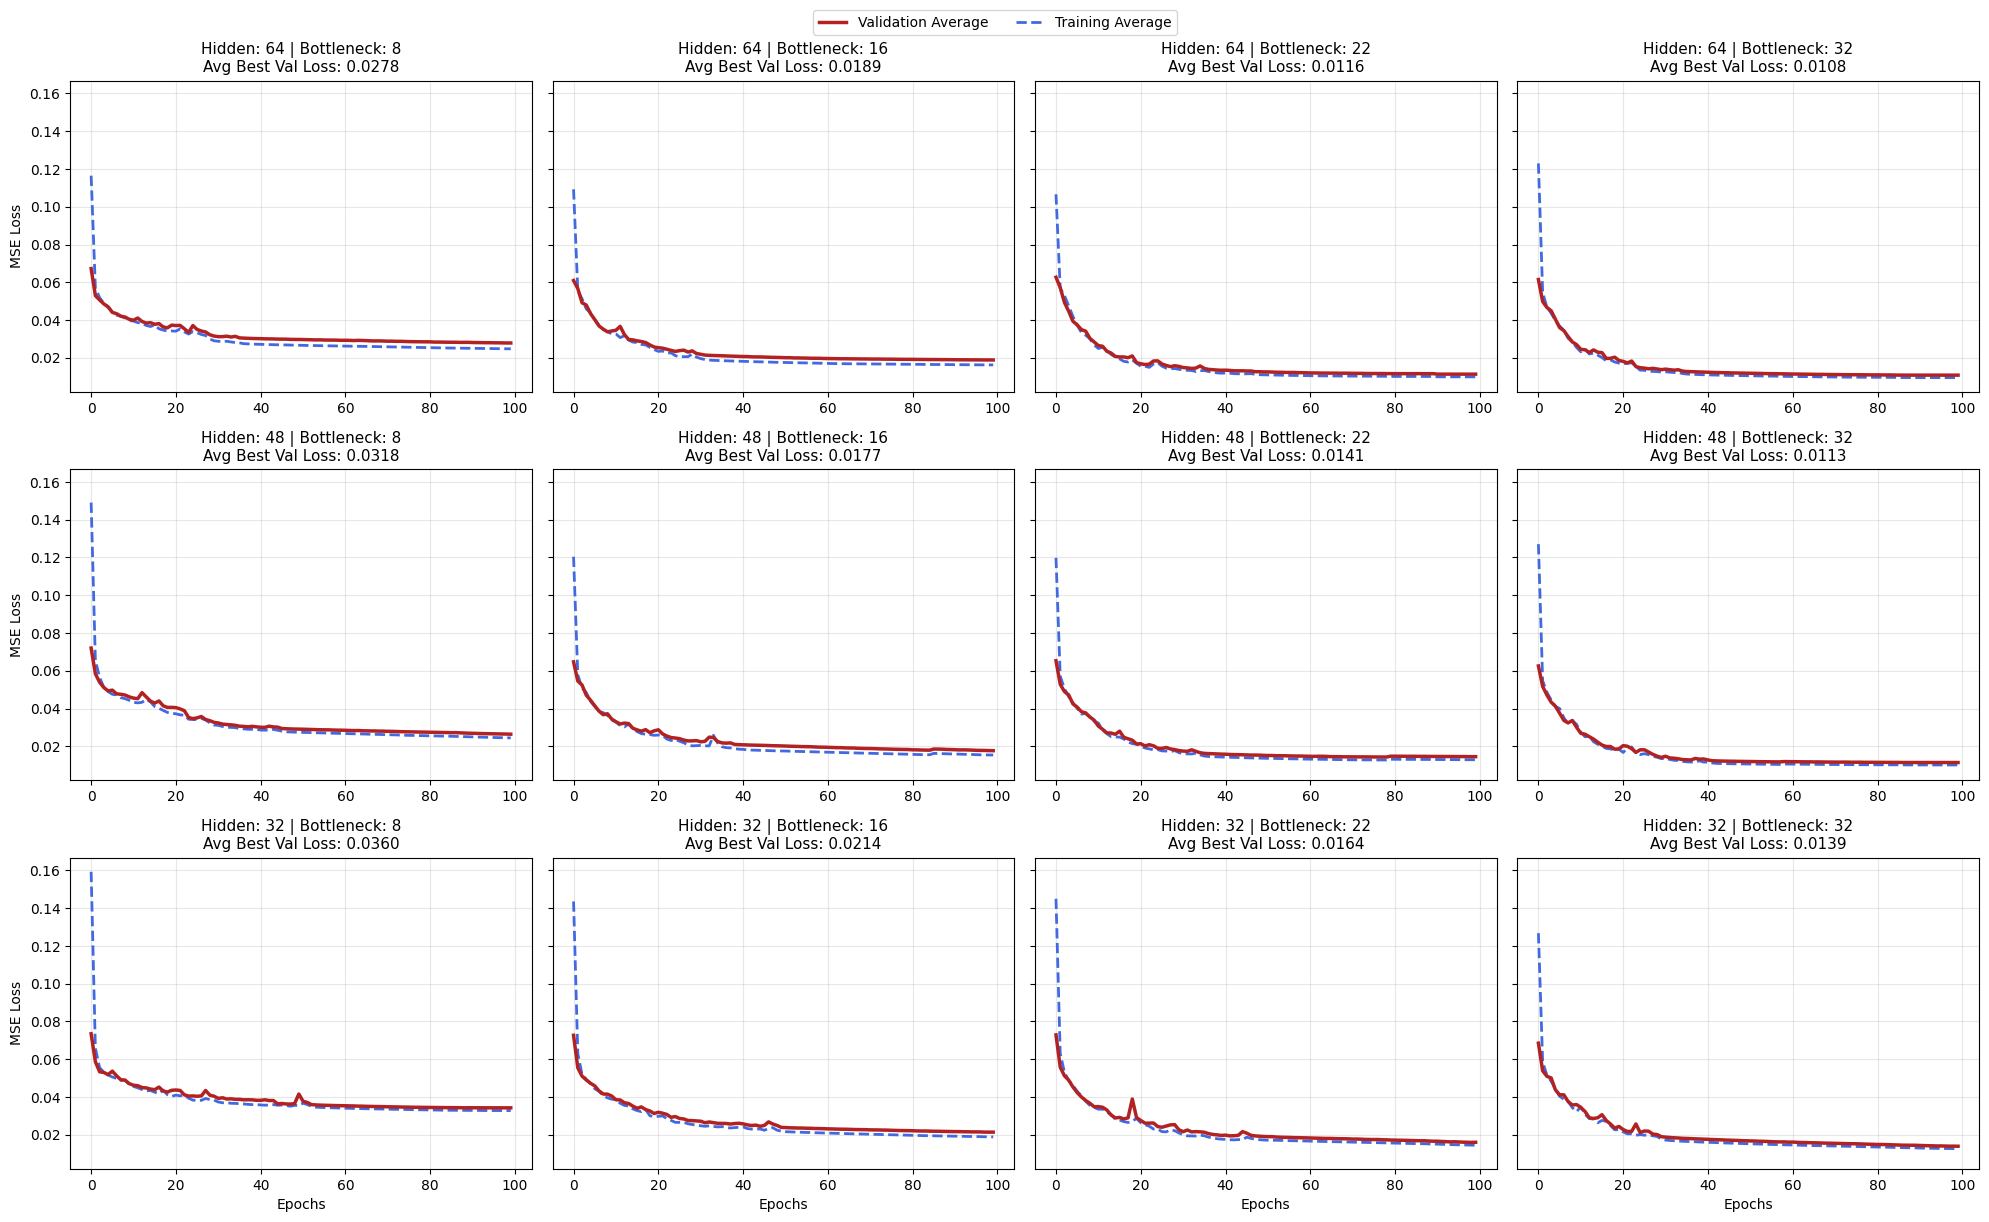

In [31]:
# --- STEP 4: The "Master Dashboard" Visualization (Averaged) ---
print("\nGenerating Analysis Plots (Averaged Lines)...")

# Create a grid of subplots
n_rows = len(hidden_sizes)
n_cols = len(bottleneck_sizes)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)

# Ensure 'axes' is always a 2D array
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1 or n_cols == 1:
    axes = np.atleast_2d(axes)
    if n_rows == 1: axes = axes.T

for i, h_dim in enumerate(hidden_sizes):
    for j, b_dim in enumerate(bottleneck_sizes):

        # Handle indexing
        if n_rows > 1 and n_cols > 1: ax = axes[i, j]
        elif n_rows > 1: ax = axes[i, 0]
        else: ax = axes[0, j]

        config_id = f"H{h_dim}_B{b_dim}"
        data = search_history[config_id]
        train_curves = data['train']
        val_curves = data['val']

        # --- AVERAGING LOGIC ---
        # 1. Find the maximum epoch reached in this config across all folds
        max_len = max(max(len(c) for c in train_curves), max(len(c) for c in val_curves))

        # 2. Prepare matrices filled with NaN (n_folds x max_len)
        train_mat = np.full((n_folds, max_len), np.nan)
        val_mat = np.full((n_folds, max_len), np.nan)

        # 3. Fill the matrices with the actual data
        for f in range(n_folds):
            train_mat[f, :len(train_curves[f])] = train_curves[f]
            val_mat[f, :len(val_curves[f])] = val_curves[f]

        # 4. Calculate the Mean (ignoring NaNs)
        # This computes the average loss at every epoch across available folds
        avg_train = np.nanmean(train_mat, axis=0)
        avg_val = np.nanmean(val_mat, axis=0)

        # --- PLOTTING ---
        # Training Mean (Dashed, Blue)
        ax.plot(avg_train, linestyle='--', linewidth=2, color='royalblue', label='Train Avg')

        # Validation Mean (Solid, Firebrick Red)
        ax.plot(avg_val, linestyle='-', linewidth=2.5, color='firebrick', label='Val Avg')

        # Formatting
        score = data['avg_score']
        ax.set_title(f"Hidden: {h_dim} | Bottleneck: {b_dim}\nAvg Best Val Loss: {score:.4f}", fontsize=11)
        ax.grid(True, alpha=0.3)

        # Labels
        if i == n_rows - 1: ax.set_xlabel("Epochs")
        if j == 0: ax.set_ylabel("MSE Loss")

# Add Legend
custom_lines = [Line2D([0], [0], color='firebrick', lw=2.5, linestyle='-'),
                Line2D([0], [0], color='royalblue', lw=2, linestyle='--')]

fig.legend(custom_lines, ['Validation Average', 'Training Average'],
           loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

Looking at the best average validation results for all architectures, we see that for a very narrow latent space, the error increases. For a latent space that is approximately half the size of the input space, the error remains low; however, as our final architecture, we are going to use a latent space of 22 neurons with 64 neurons in the hidden layers, since it compresses the input space more effectively while maintaining a very similar error rate to the latent space with half the features.

Now we will train our autoencoder on the full dataset to extract the latent representations (centroids) for use in the subsequent clustering process.

In [ ]:
# --- STEP 5: Retrain & Save Encoder Weights ---
# Now that we know the best params, we train on the FULL dataset (all 1274 rows)
print("\n--- Retraining Final Model on Full Data ---")

# Rebuild Best Model
final_input = Input(shape=(n_features,))
final_enc_h = Dense(64, activation="relu")(final_input)
final_bottle = Dense(22, activation="relu", name="bottleneck")(final_enc_h)
final_dec_h = Dense(64, activation="relu")(final_bottle)
final_output = Dense(n_features, activation="linear")(final_dec_h)

final_model = Model(inputs=final_input, outputs=final_output)
final_model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

# Train on ALL data (X, not X_train)
callbacks_no_val = [
    # 1. Reduce LR based on Training Loss
    # If the model struggles to lower the error on your data, slow down the learning rate
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.1,
        patience=4,
        min_lr=0.00001,
        verbose=1
    ),

    # 2. Early Stopping based on Training Loss
    # Stop if the model basically hits a wall and can't improve reconstruction
    EarlyStopping(
        monitor='loss',
        min_delta=0.0001,
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

final_model.fit(
    X, X,
    sample_weight=weights,
    epochs=200,
    batch_size=32,
    validation_split=0.0,
    callbacks=callbacks_no_val,
    verbose=0
)

# Extract JUST the Encoder part (up to bottleneck)
encoder_model = Model(inputs=final_model.input, outputs=final_model.get_layer("bottleneck").output)

# Save weights
save_path = "best_encoder_weights.weights.h5"
encoder_model.save_weights(save_path)


--- Retraining Final Model on Full Data ---

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0004999999888241291.

Epoch 80: ReduceLROnPlateau reducing learning rate to 4.9999996554106475e-05.

Epoch 85: ReduceLROnPlateau reducing learning rate to 1e-05.
Epoch 96: early stopping
Restoring model weights from the end of the best epoch: 86.


Now that we have the weights saved, we are going to load them into the encoder part, which is the component that compresses our input space.

In [24]:
# --- CONFIGURATION (MUST Match Training Exactly) ---
n_features = df_centroids.shape[1]
best_hidden = 64     # Replace with your best result
best_bottleneck = 22  # Replace with your best result
weights_path = "best_encoder_weights.weights.h5"

# --- 1. Rebuild the Model Skeleton ---
# We only need the ENCODER part now, because we don't care about decoding anymore.
input_layer = Input(shape=(n_features,))
encoder_h = Dense(best_hidden, activation="relu")(input_layer)
bottleneck = Dense(best_bottleneck, activation="relu", name="bottleneck")(encoder_h)

# Create the model object
loaded_encoder = Model(inputs=input_layer, outputs=bottleneck)

# --- 2. Load the Weights ---
loaded_encoder.load_weights(weights_path)

print("Weights loaded successfully!")

Weights loaded successfully!


And let's compress all of our centroids into the new latent features.

In [25]:
latent_vectors = loaded_encoder.predict(X)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


## <a id='toc1_10_'></a>[Hierarchical](#toc0_)

Let's start by analyzing the number of clusters by examining the dendrogram.

In [26]:
linkage_matrix= linkage(latent_vectors, method="ward")

In [27]:
linkage_matrix.shape

(1273, 4)

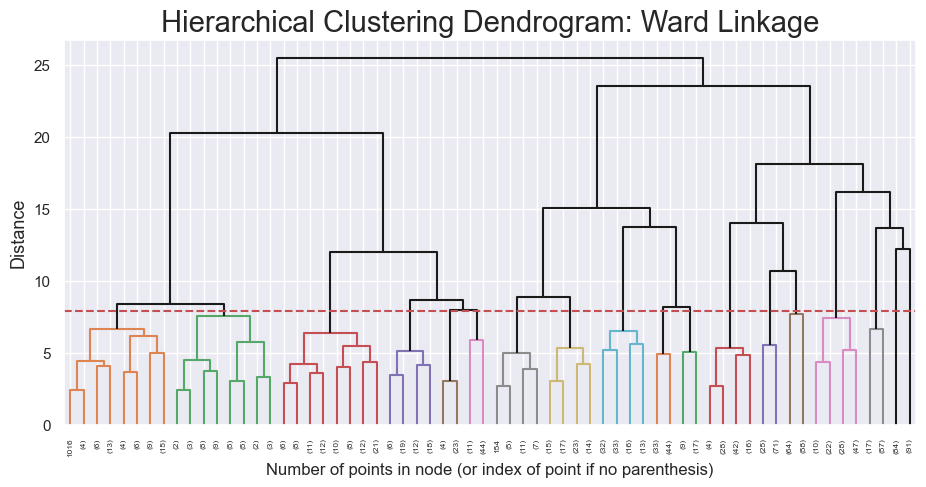

In [28]:
# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 7.9
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    # You can play with 'truncate_mode' and 'p' define what level the dendrogram shows
    # above_threshold_color='k' forces black color for the lines above the threshold)
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Distance', fontsize=13)
plt.show()

We see that partitioning into 18 clusters could provide a good clustering merge solution, so we will test it and analyse the results.

In [29]:
# Performing HC
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=18)
hc_labels = hclust.fit_predict(latent_vectors)
hc_labels

array([15, 15,  6, ...,  2,  2, 15])

In [30]:
hc_cluster_names = {0: 'The October Loyals',
                    1: 'The Pandemic Drop-offs',
                    2: 'The September Loyals',
                    3: 'The January Average',
                    4: 'The Summer-Fall Hybrids',
                    5: 'The May Planners',
                    6: 'The Lost Holiday Drifters',
                    7: 'The Autumn Budget',
                    8: 'The June Loyals',
                    9: 'Holiday Travelers',
                    10: 'The November Loyals',
                    11: 'The Dormant Browsers',
                    12: 'The March Loyals',
                    13: 'VIPs',
                    14: 'The Q4 Boomerang',
                    15: 'The December Loyals',
                    16: 'The February Loyals',
                    17: 'New travelers'}

hc_labels = pd.Series(hc_labels).map(hc_cluster_names).values
hc_labels


array(['The December Loyals', 'The December Loyals',
       'The Lost Holiday Drifters', ..., 'The September Loyals',
       'The September Loyals', 'The December Loyals'], dtype=object)

In [31]:
df_centroids['merged_labels'] = hc_labels
df_centroids

Latitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                -0.800379   
                                                                                                          High-Value Frequent Flyers  -0.855160   
                                                                                                          High-Value Low transactions -0.924640   
                                                                                                          Long-tenure                 -0.815406   
                                                                                                          New engaged                 -0.784981   
...                                                                                                                                         ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                 -0.186616   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                -0.213367   
                                                                                                          High-Value Frequent Flyers  -0.086938   
                                                                                                          Long-tenure                 -0.186024   
                                                                                                          New engaged                 -0.220781   

                                                                                                                                       Longitude  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                 
High-Income East         Consistent low travelers\r\n(Use points) Avr|Dec Companion\n(Less travel on dec) Fly fanatics                  0.583344   
                                                                                                          High-Value Frequent Flyers    0.399303   
                                                                                                          High-Value Low transactions   0.352217   
                                                                                                          Long-tenure                   0.454108   
                                                                                                          New engaged                   0.456025   
...                                                                                                                                          ...   
Low-Income West          Stable average travelers\r\n(Loyal)      Avr|Point Acumulator\n(No companions)   New engaged                  -0.609297   
                                                                  Moderate travelers\n(Current average)   Fly fanatics                 -0.643435   
                                                                                                          High-Value Frequent Flyers   -0.549443   
                                                                                                          Long-tenure                  -0.589795   
                                                                                                          New engaged                  -0.079026   

                                                                                                                                         Income  \
Demographic_Cluster_Name Behavioral_Year_Cluster_Name             Behavioral_Month_Cluster_Name           Value_Based_Cluster_Name                
High

In [32]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
inverse_cluster_mapper = {}

for key, value in cluster_mapper.items():
    # If the value isn't in the new dict yet, create a list
    if value not in inverse_cluster_mapper:
        inverse_cluster_mapper[value] = []

    # Append the original key to that list
    inverse_cluster_mapper[value].append(key)
inverse_cluster_mapper

{'The December Loyals': [('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'Fly fanatics'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'High-Value Frequent Flyers'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'Long-tenure'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'New engaged'),
  ('High-Income East',
   'Consistent low travelers\r\n(Use points)',
   'Holiday traveler\n(summer companions, winter alone)',
   'High-Value Frequent Flyers'),
  ('High-Income East',
   'Formers Points accumulator\r\n(2020)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'Fly fanatics'),
  ('High-Income East',
   'Formers Points accumulator\r\n(2020)',
   'Avr|Dec Companion\n(Less travel on dec)',
   'High-Value 

In [33]:
df_multi_perspective['merged_labels'] = df_multi_perspective.apply(
    lambda row: cluster_mapper[(row['Demographic_Cluster_Name'], row['Behavioral_Year_Cluster_Name'], row['Behavioral_Month_Cluster_Name'], row['Value_Based_Cluster_Name'])],
    axis=1
)

hc_final_label = df_multi_perspective['merged_labels']

Now we will see the number of customers assigned to each of the clusters.

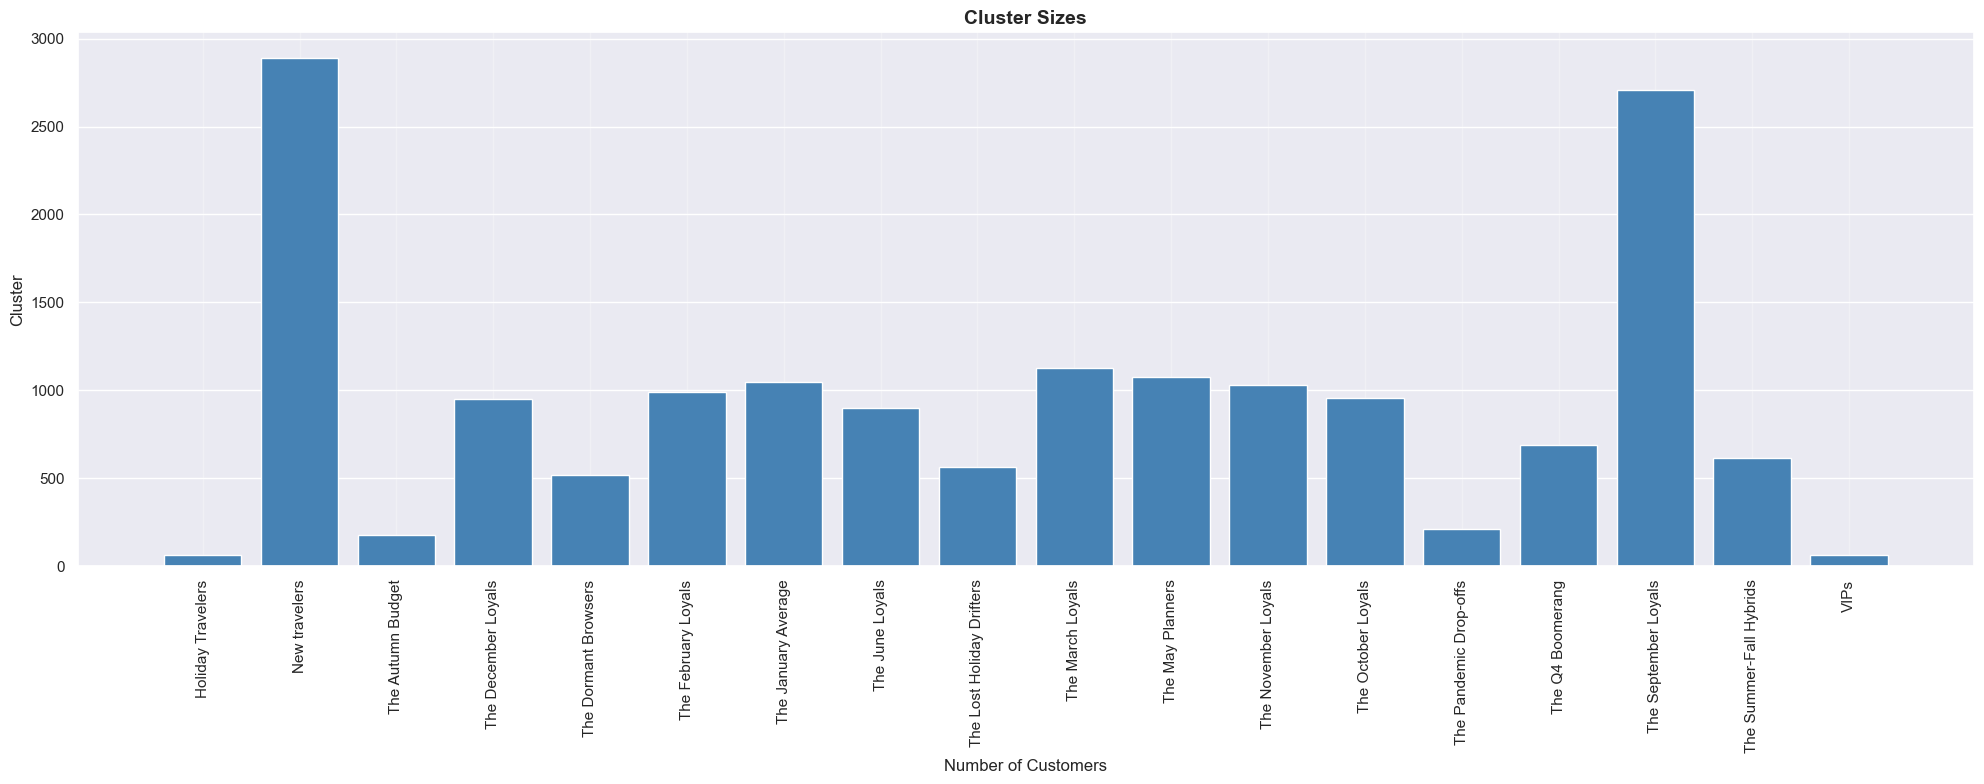

In [34]:
all_segments=df_centroids
fig, ax2 = plt.subplots( 1, figsize=(20, 8))

cluster_sizes = df_multi_perspective['merged_labels'].value_counts().sort_index()

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color='steelblue')
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

And see how they behave.

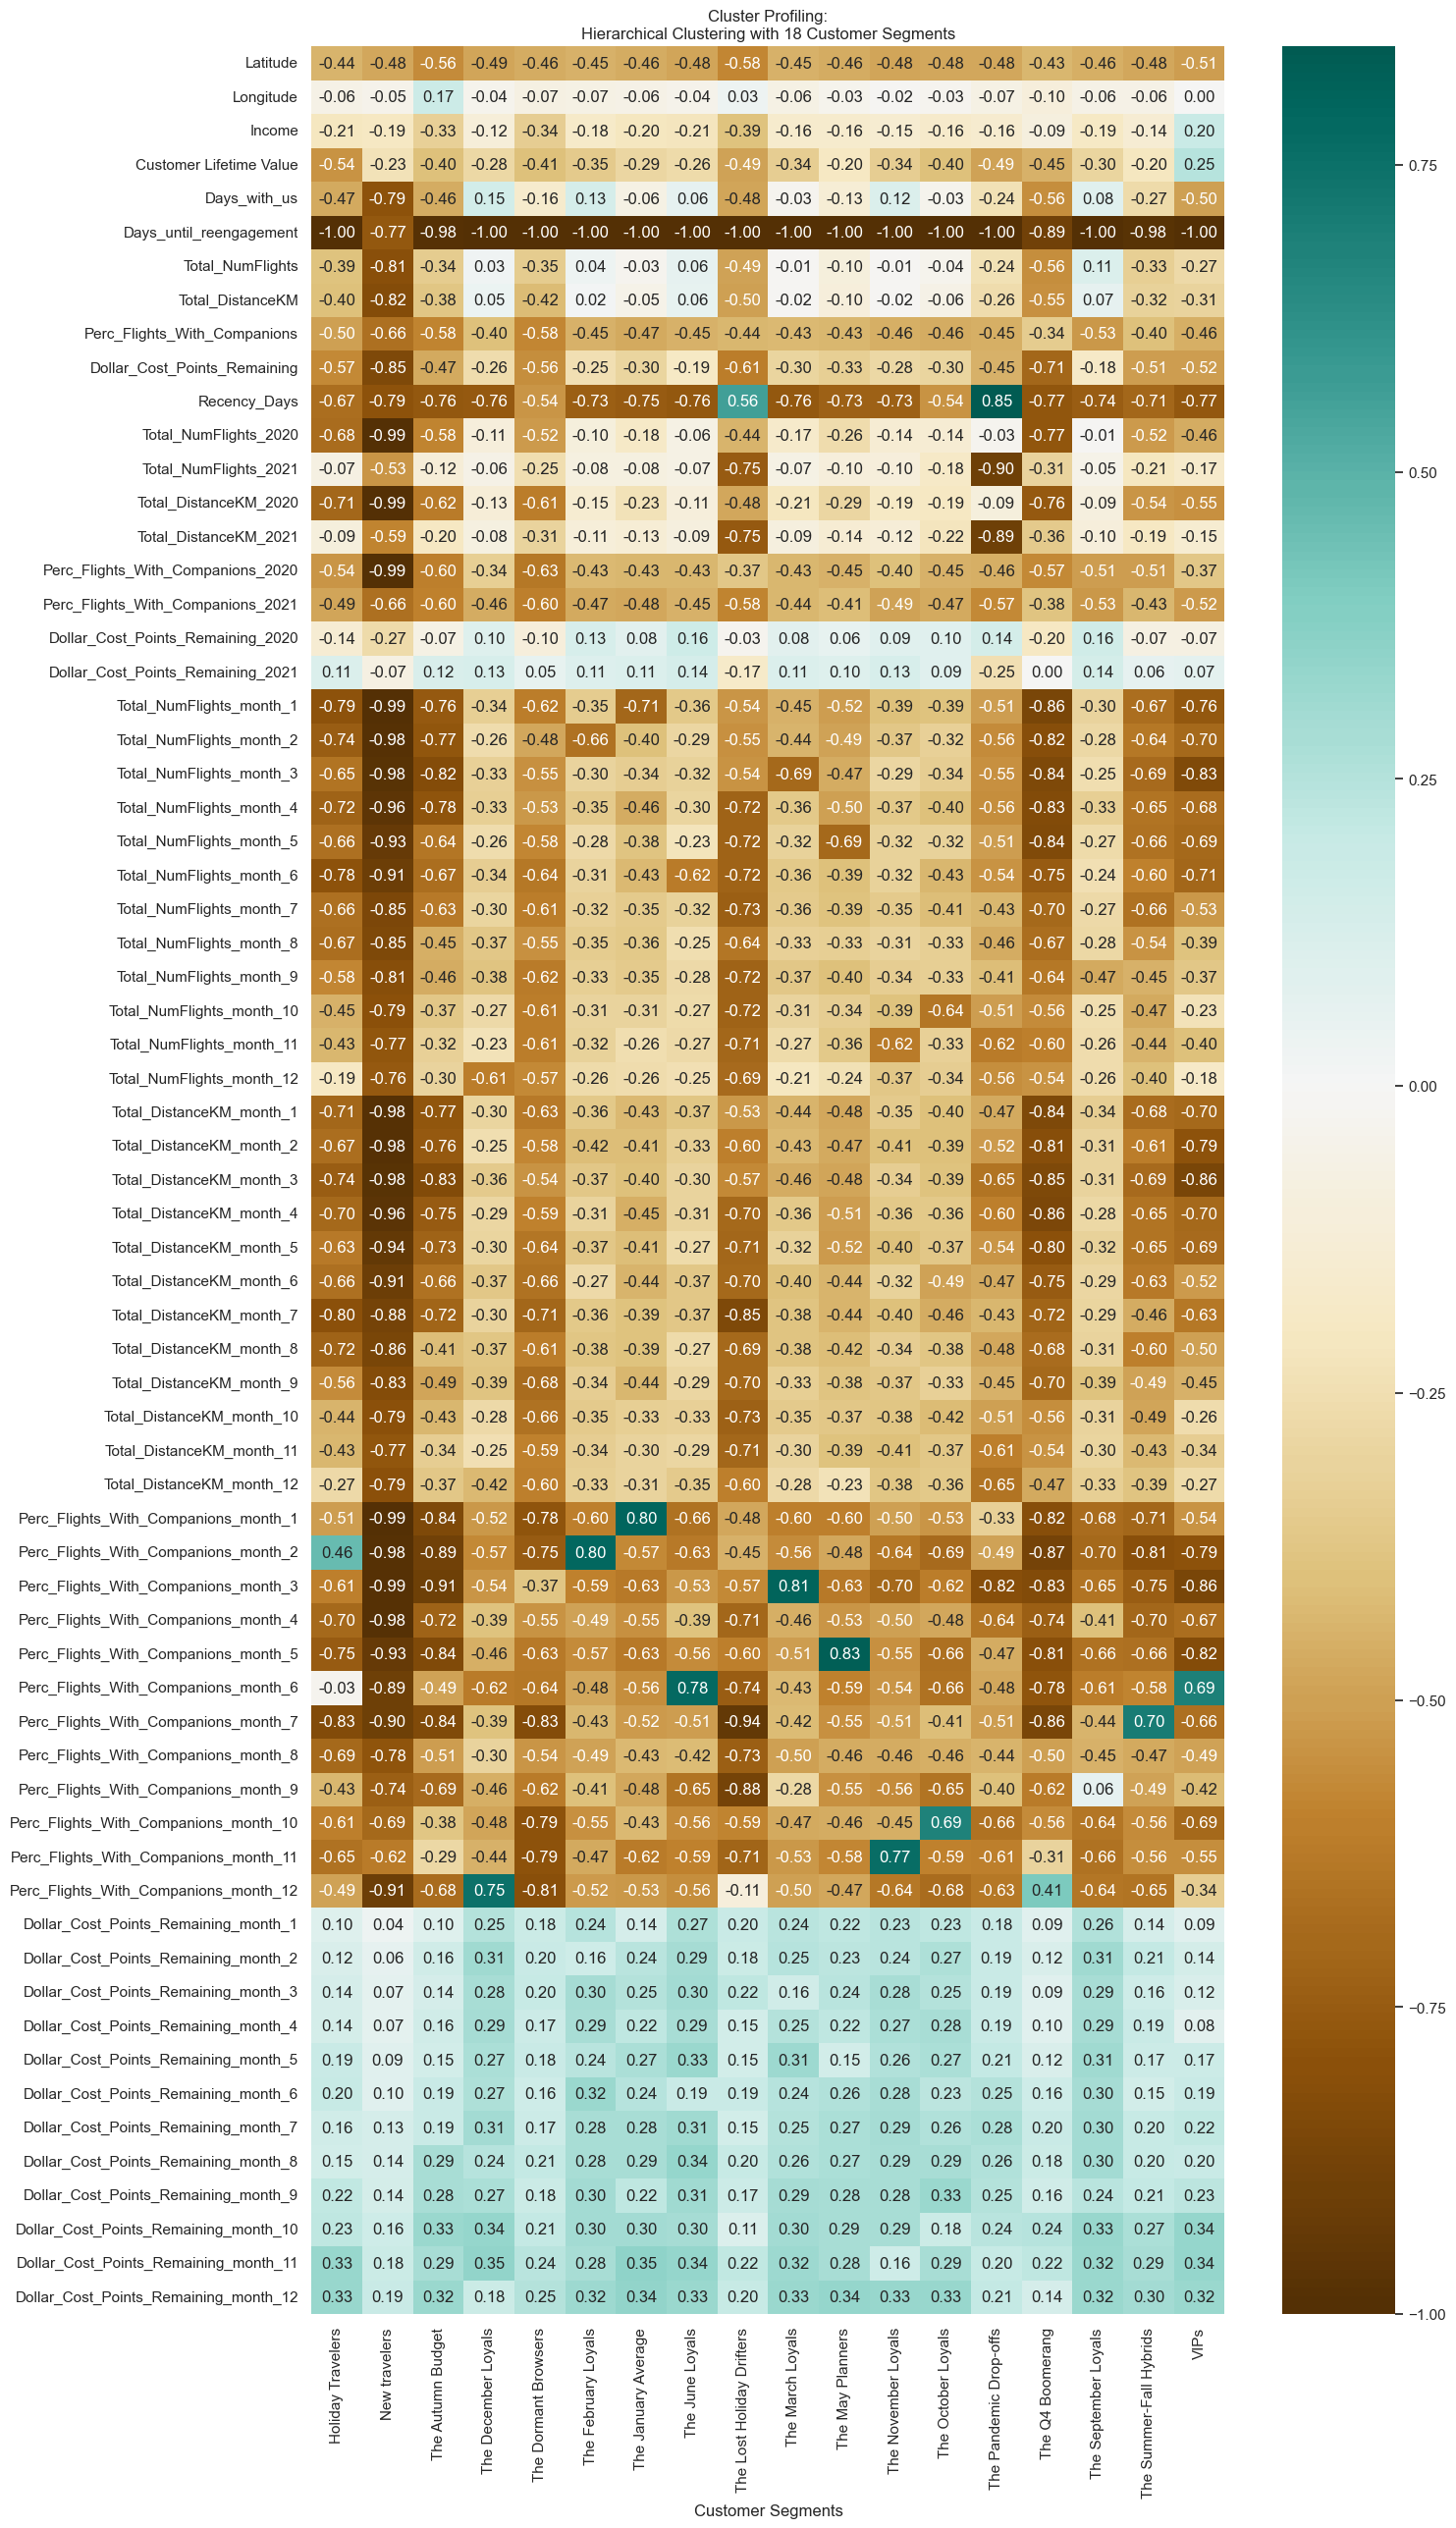

In [35]:
fig, ax = plt.subplots(figsize=(15, 30))

# Compute cluster profiles
km_profile = df_centroids.groupby('merged_labels').mean().T

# Rename cluster columns using your mapping


sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 18 Customer Segments")
plt.show()

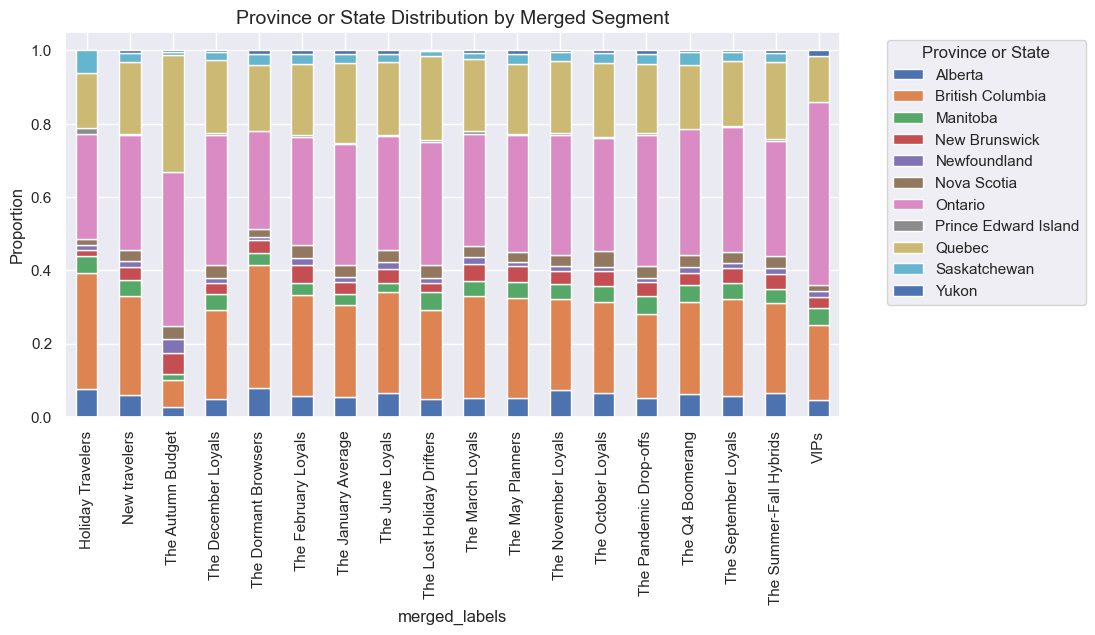

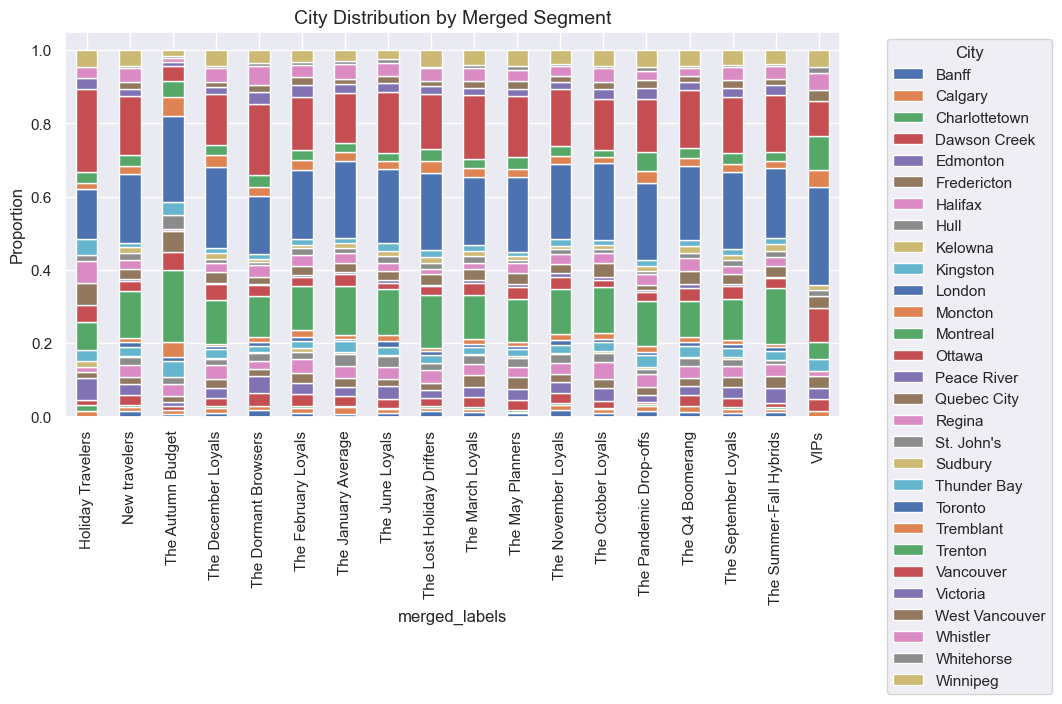

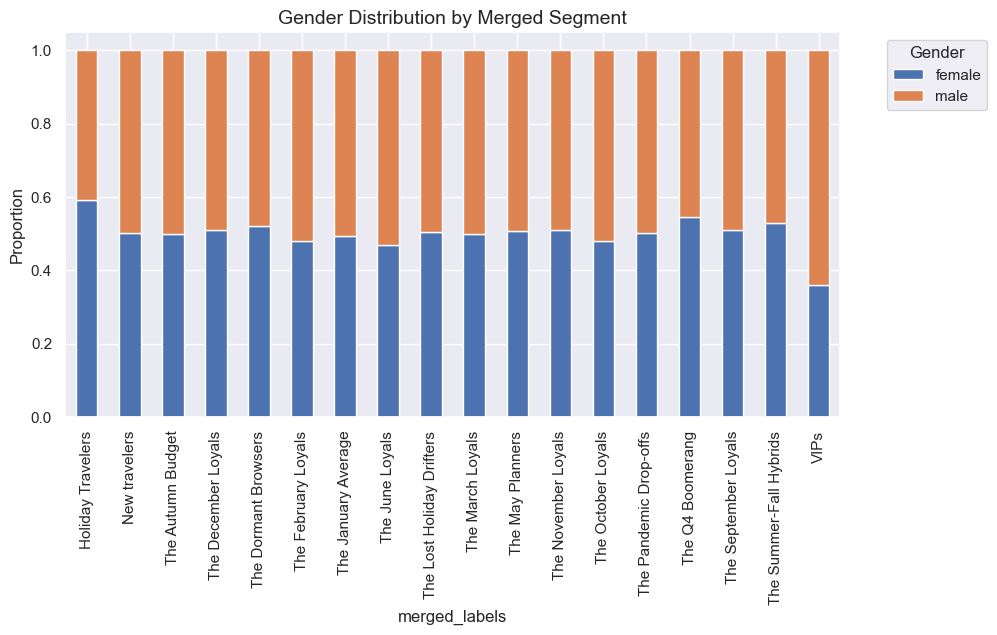

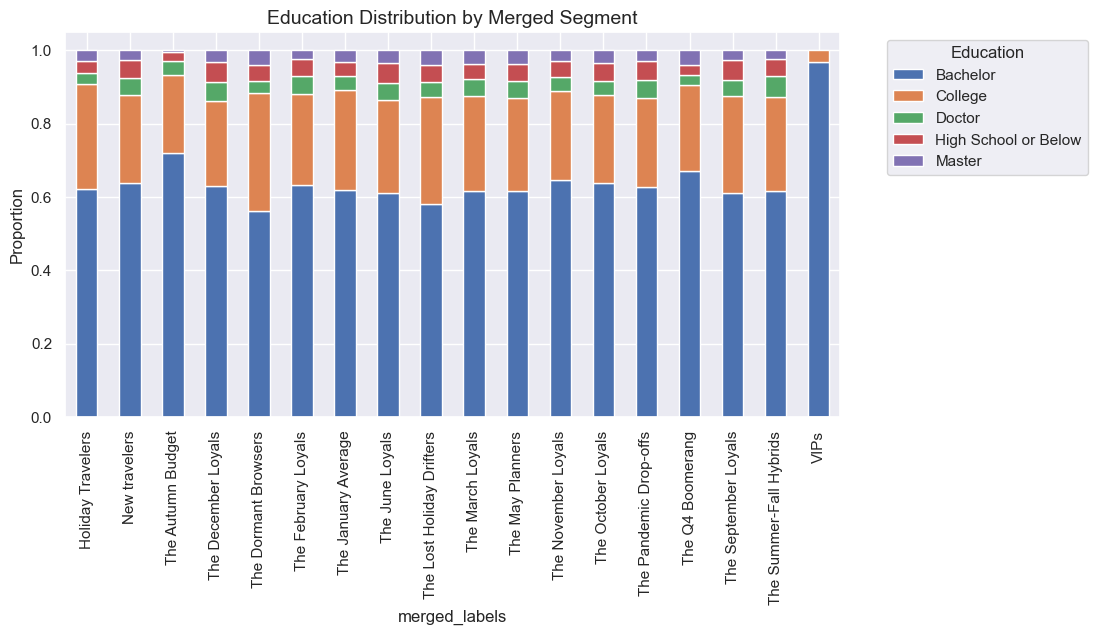

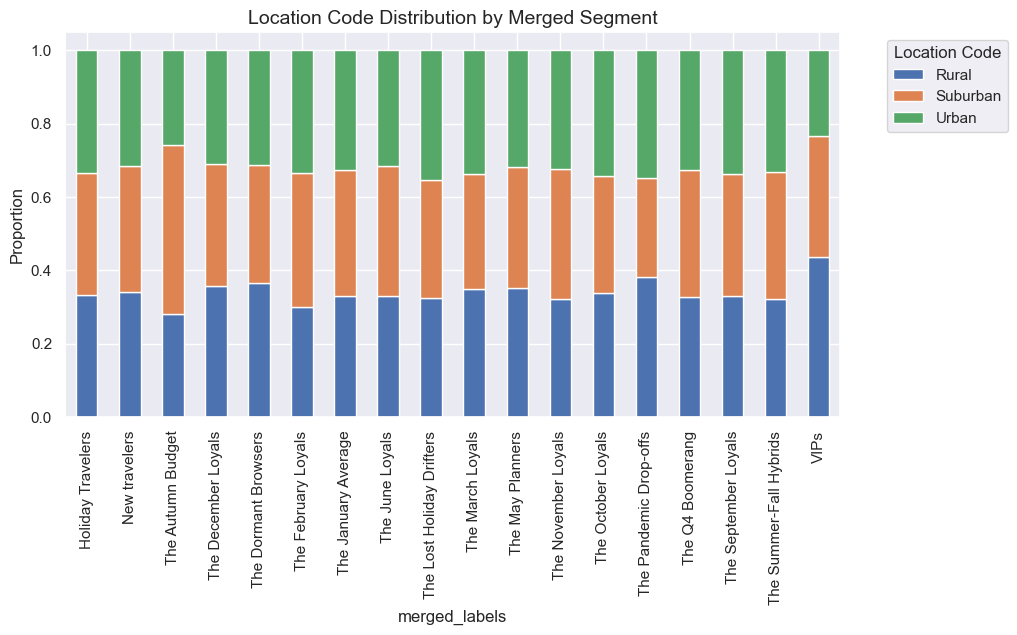

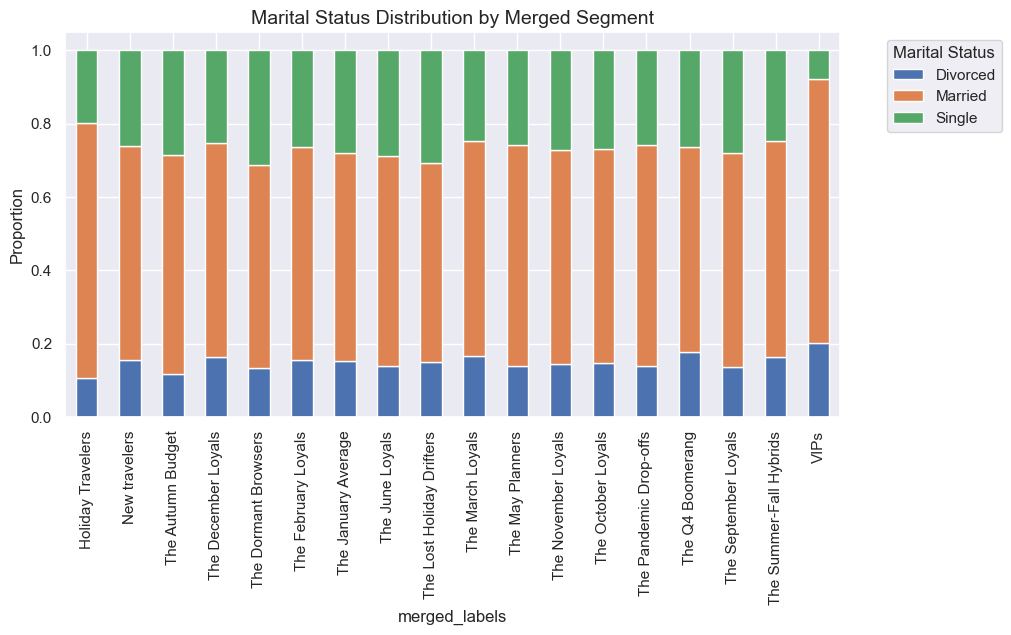

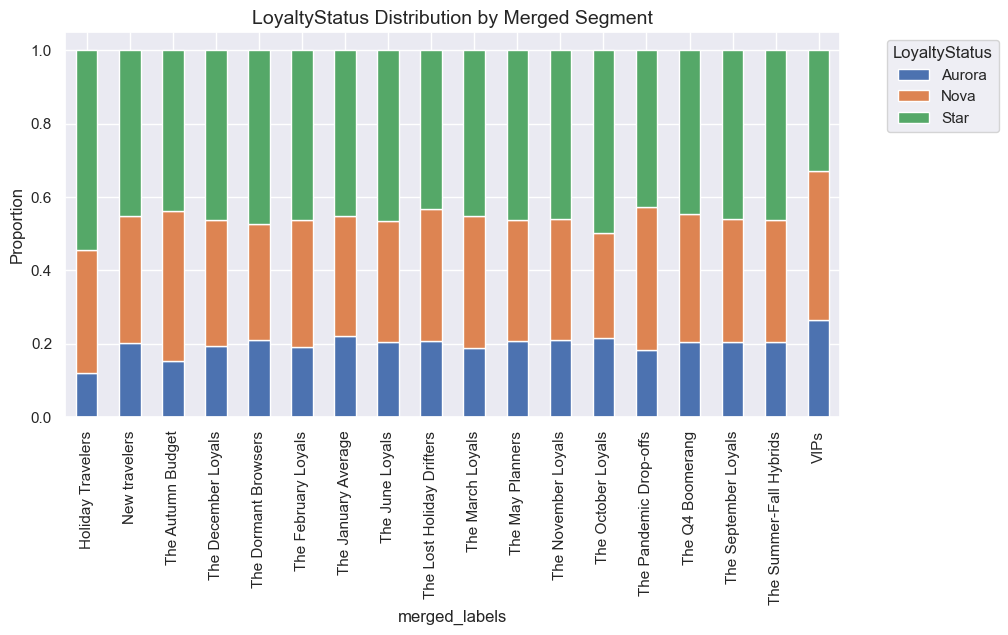

In [36]:
categorical = ['Province or State', 'City', 'Gender', 'Education',
               'Location Code', 'Marital Status', 'LoyaltyStatus']

for col in categorical:
    pd.crosstab(df_multi_perspective['merged_labels'],
                df_multi_perspective[col],
                normalize='index').plot.bar(
        stacked=True,
        figsize=(10, 5)
    )
    plt.title(f"{col} Distribution by Merged Segment", fontsize=14)
    plt.ylabel("Proportion")
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

**Profiling:**

First, we observe that longitude and latitude lose their significance as they remain almost constant across all clusters, while the other variables used to build the clusters vary significantly depending on the group.

Regarding categorical variables, most clusters do not change much; only one or two clusters show behavioral shifts in variables such as Province or State, City, Education, and Marital Status.

Here is the profiling for each cluster:

+ **The October Loyals (956):** Medium income, low revenue, long tenure. They have not purchased recently but remain a consistent, engaged group over the years. These are "October people" who accumulate points year-round to use in October when they fly less but with companions.

+ **The Pandemic Drop-offs (209):** Medium income, low revenue, moderate tenure. These are lost customers who were active in 2019 and 2020 but stopped almost completely in 2021. They previously traveled with consistent frequency and distance each month.

+ **The September Loyals (2706):** Medium income, low revenue, long tenure. Loyal, very engaged customers who purchased recently. "September people" who save points all year to use in September for flights with companions.

+ **The January Average (1045):** Medium income, low revenue, long tenure. Recently active and traveling more now than before (highly engaged). "January people" who use accumulated points for companion travel in January.

+ **The Summer-Fall Hybrids (613):** Medium income, medium revenue, moderate tenure. Recently active and showing increased engagement. "July people" who travel with companions in July and tend to travel alone in autumn.

+ **The May Planners (1078):** Medium income, medium revenue, moderate tenure. Recently active and now very engaged. "May people" who accumulate points to use during May for companion travel.

+ **The Lost Holiday Drifters (565):** Low income, low revenue, short tenure. Lost customers who were never highly engaged; they use points and tend to travel more with companions in December.

+ **The Autumn Budget (178):** Low income, low revenue, short tenure. Recently active and becoming more engaged, specifically during the autumn months.

+ **The June Loyals (897):** Medium income, medium revenue, long tenure. Very engaged, loyal customers. "June people" who save points all year for companion travel in June.

+ **Holiday Travelers (66):** Medium income, low revenue, short tenure. Recently active and increasing engagement. They travel with companions in February and June, using points in most months except November and December (when they travel the most).

+ **The November Loyals (1029):** Medium income, medium revenue, long tenure. Consistent, engaged group. "November people" who redeem points for companion travel in November.

+ **The Dormant Browsers (517):** Low income, low revenue, moderate tenure. Have not purchased recently but show some new engagement; they travel consistently but infrequently across all months and use points.

+ **The March Loyals (1126):** Medium income, medium revenue, long tenure. Consistent, engaged group. "March people" who accumulate points for companion travel in March.

+ **VIPs (64):** High income, high revenue, short tenure. Recently active and engaged. They travel in June with companions and are frequent autumn travelers, using points throughout the year except in Q4. Almost 100% Bachelors, that are Divorced or Married, with the more proportion of mens (~35%).

+ **The Q4 Boomerang (691):** Medium income, low revenue, short tenure. Re-engaged customers who are now moderately active, particularly in autumn and December with companions.

+ **The December Loyals (949):** Medium income, medium revenue, long tenure. Very engaged, loyal customers. "December people" who redeem points for companion travel in December.

+ **The February Loyals (992):** Medium income, low revenue, long tenure. Very engaged, loyal customers. "February people" who save points for companion travel in February.

+ **New travelers (2891):** Medium income, medium revenue, very short tenure (newest). Re-engaged, moderately active customers who use points and travel primarily in autumn.

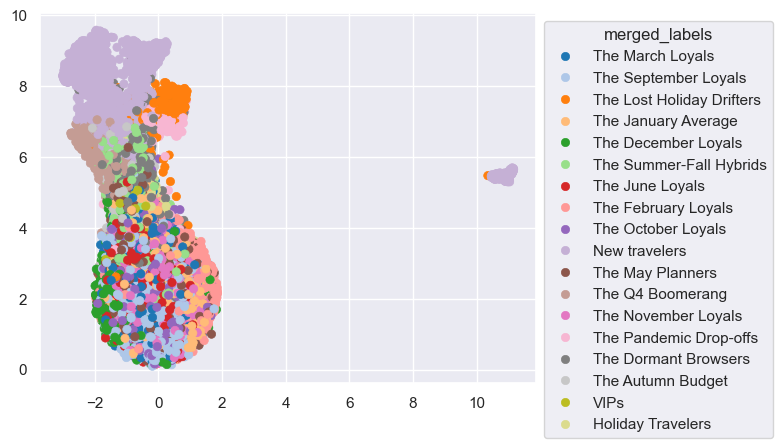

In [37]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(umap_for_modeling)
targets = df_multi_perspective['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Looking at all of our customers, we see that the majority of clusters overlap because there are too many observations and too many features to effectively compress into two dimensions.

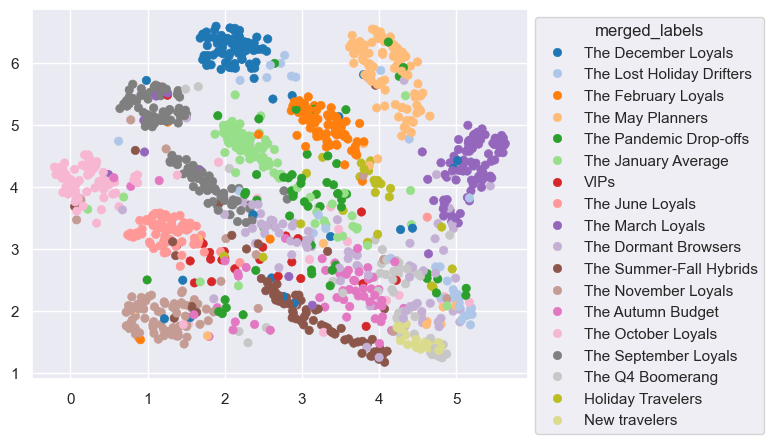

In [38]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(df_centroids.drop(columns=['merged_labels']))
targets = df_centroids['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Looking only at the centroids of our original features, we see that hierarchical clustering manages to split the customers, with some exceptions that tend to cluster together.

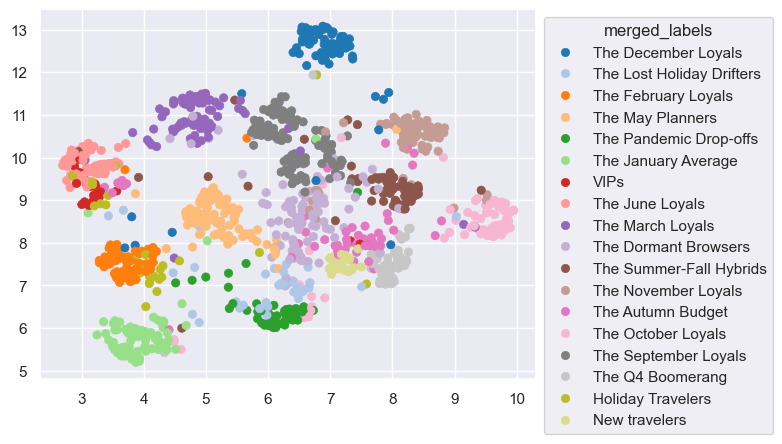

In [39]:
umap_original = umap.UMAP(n_neighbors = 100, random_state = 0).fit_transform(latent_vectors)
targets = df_centroids['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Looking only at the centroids of our latent features, we see that hierarchical clustering manages to split the customers, very well, meaining that our latent features actually improve the work of the cluster models.

In [40]:
X = umap_for_modeling.values

# Computing SST
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

# Computing SSW
ssw_iter = []                   # Outer summation
for i in np.unique(df_multi_perspective['merged_labels']):  # Loop for inner summation
    X_k = X[df_multi_perspective['merged_labels'] == i]     # Data points belonging to cluster k
    inner_sum = np.sum(np.square(X_k - X_k.mean(axis=0)), axis=0)
    ssw_iter.append(inner_sum)
ssw_per_feature = np.sum(ssw_iter, axis=0)  # Outer summation
ssw = np.sum(ssw_per_feature, axis=0)

# Computing SSB
ssb_iter = []
for i in np.unique(df_multi_perspective['merged_labels']):  # Loop for summation
    X_k = X[df_multi_perspective['merged_labels'] == i]     # Data points belonging to cluster k
    ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))

ssb_per_feature = np.sum(ssb_iter, axis=0)
ssb = np.sum(ssb_per_feature, axis=0)

In [41]:
sil_hc = silhouette_score(X, df_multi_perspective['merged_labels'])

hc_row = pd.DataFrame([{
    'num_clusters': len(np.unique(df_multi_perspective['merged_labels'])),
    'ssw (Lower is better, 0 to +∞)': ssw,
    'ssb (Higher is better, 0 to SST)': ssb,
    'silhouette_score (Higher is better, −1 to +1)': sil_hc,
    'r2 (Higher is better, 0 to 1)': ssb / sst,
    'Method': 'Hierarchical'
}])

column_order = [
    'Method',
    'num_clusters',
    'r2 (Higher is better, 0 to 1)',
    'silhouette_score (Higher is better, −1 to +1)',
    'ssw (Lower is better, 0 to +∞)',
    'ssb (Higher is better, 0 to SST)'
]

hc_row = hc_row[column_order]

display(hc_row)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,Hierarchical,18,0.307923,0.064537,171770.312253,76424.97939


## <a id='toc1_11_'></a>[K-Means](#toc0_)

Now we will use K-Means on the latent space of the centroids to see if it generates better clusters.

In [42]:
X = latent_vectors

# Compute SST once (constant for all clusterings)
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

results = []

for n_clusters in range(2, 25):  # Test from 2 to 10 clusters
    kmclust = KMeans(n_clusters=n_clusters, init='k-means++', random_state=22)
    labels = kmclust.fit_predict(latent_vectors)

    # ---- SSW ----
    ssw = kmclust.inertia_

    # ---- SSB ----
    ssb_iter = []
    for i in np.unique(labels):
        X_k = X[labels == i]
        ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))
    ssb_per_feature = np.sum(ssb_iter, axis=0)
    ssb = np.sum(ssb_per_feature, axis=0)

    # ---- Silhouette ----
    sil_score = silhouette_score(X, labels)

    results.append({
        'num_clusters': n_clusters,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'silhouette_score (Higher is better, −1 to +1)': sil_score,
        'r2 (Higher is better, 0 to 1)': ssb / sst,


    })

df_cluster_metrics = pd.DataFrame(results)

df_cluster_metrics

,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","silhouette_score (Higher is better, −1 to +1)","r2 (Higher is better, 0 to 1)"
0,2,3470.806152,477.107483,0.148426,0.120851
1,3,3183.755859,764.157349,0.118628,0.193560
2,4,3041.652832,906.260254,0.080293,0.229554
3,5,2928.362061,1019.551270,0.080054,0.258251
4,6,2716.756348,1231.157227,0.098645,0.311850
5,7,2580.828125,1367.085449,0.111014,0.346280
6,8,2491.089844,1456.822876,0.125157,0.369011
7,9,2410.339111,1537.573853,0.132484,0.389465
8,10,2347.146729,1600.766357,0.128503,0.405471
9,11,2253.641357,1694.271484,0.139408,0.429156


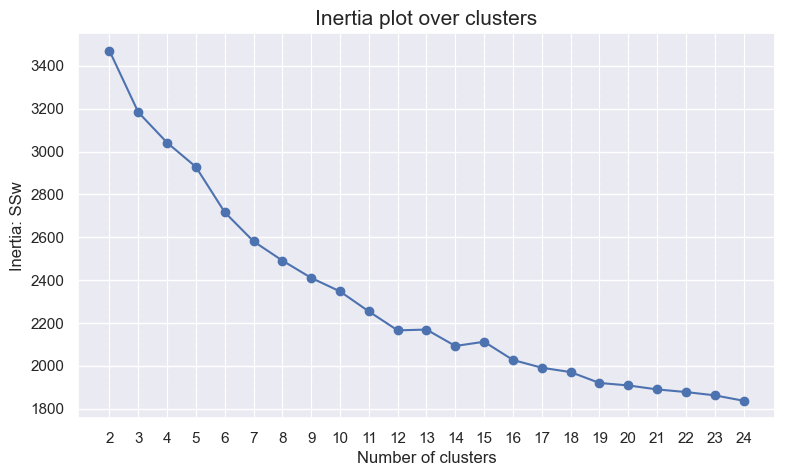

In [43]:
fig, ax = plt.subplots(figsize=(9,5))

range_clusters= list(range(2,25))
inertia= df_cluster_metrics['ssw (Lower is better, 0 to +∞)']
ax.plot(range_clusters, inertia, marker='o', zorder=2)
ax.set_xticks(list(range_clusters))

# draw vertical dashed background lines at each cluster number
for x in range_clusters:
    ax.axvline(x, color='lightgray', linestyle='--', linewidth=1, zorder=0, alpha=0.7)

ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

We will use k = 14 because that is where we see an elbow in the inertia, and it also yielded a better silhouette score compared to neighboring solutions.

In [44]:
number_clusters = 14
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(latent_vectors)
km_labels

array([ 6, 10,  5, ...,  8,  8,  6], dtype=int32)

In [45]:
km_cluster_names = {0: 'The October Loyals',
                    1: 'The Autumn Risers',
                    2: 'The June Jetsetters',
                    3: 'The February Loyals',
                    4: 'The November Loyals',
                    5: 'The May Loyals',
                    6: 'The December Loyals',
                    7: 'The Dormand Travelers',
                    8: 'Fly Fanatic',
                    9: 'The Travler Family',
                    10: 'The January Loyals',
                    11: 'The Solo Traveler',
                    12: 'The Q4 Boomerang',
                    13: 'The Lost Soloists'}

km_labels = pd.Series(km_labels).map(km_cluster_names).values
km_labels

array(['The December Loyals', 'The January Loyals', 'The May Loyals', ...,
       'Fly Fanatic', 'Fly Fanatic', 'The December Loyals'], dtype=object)

Now we will see the number of customers assigned to each of the clusters.

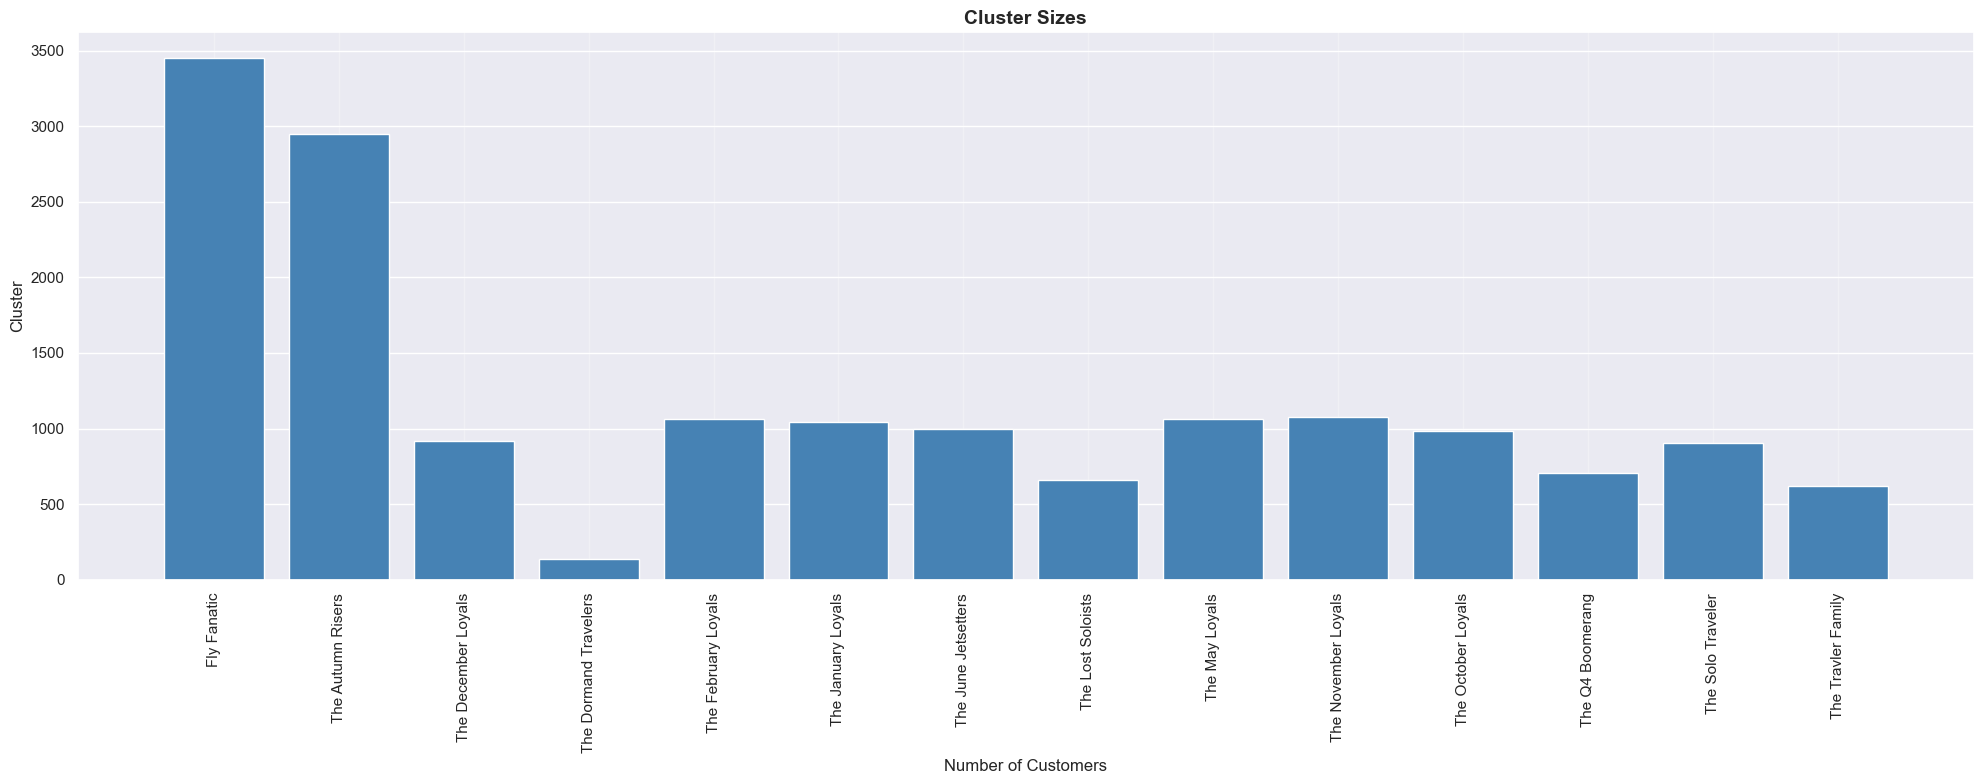

In [46]:
df_centroids['merged_labels'] = km_labels

cluster_mapper = df_centroids['merged_labels'].to_dict()
inverse_cluster_mapper = {}

for key, value in cluster_mapper.items():
    # If the value isn't in the new dict yet, create a list
    if value not in inverse_cluster_mapper:
        inverse_cluster_mapper[value] = []

    # Append the original key to that list
    inverse_cluster_mapper[value].append(key)

df_multi_perspective['merged_labels'] = df_multi_perspective.apply(
    lambda row: cluster_mapper[(row['Demographic_Cluster_Name'], row['Behavioral_Year_Cluster_Name'], row['Behavioral_Month_Cluster_Name'], row['Value_Based_Cluster_Name'])],
    axis=1
)

all_segments=df_centroids
fig, ax2 = plt.subplots( 1, figsize=(20, 8))

cluster_sizes = df_multi_perspective['merged_labels'].value_counts().sort_index()

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color='steelblue')
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

And see how they behave.

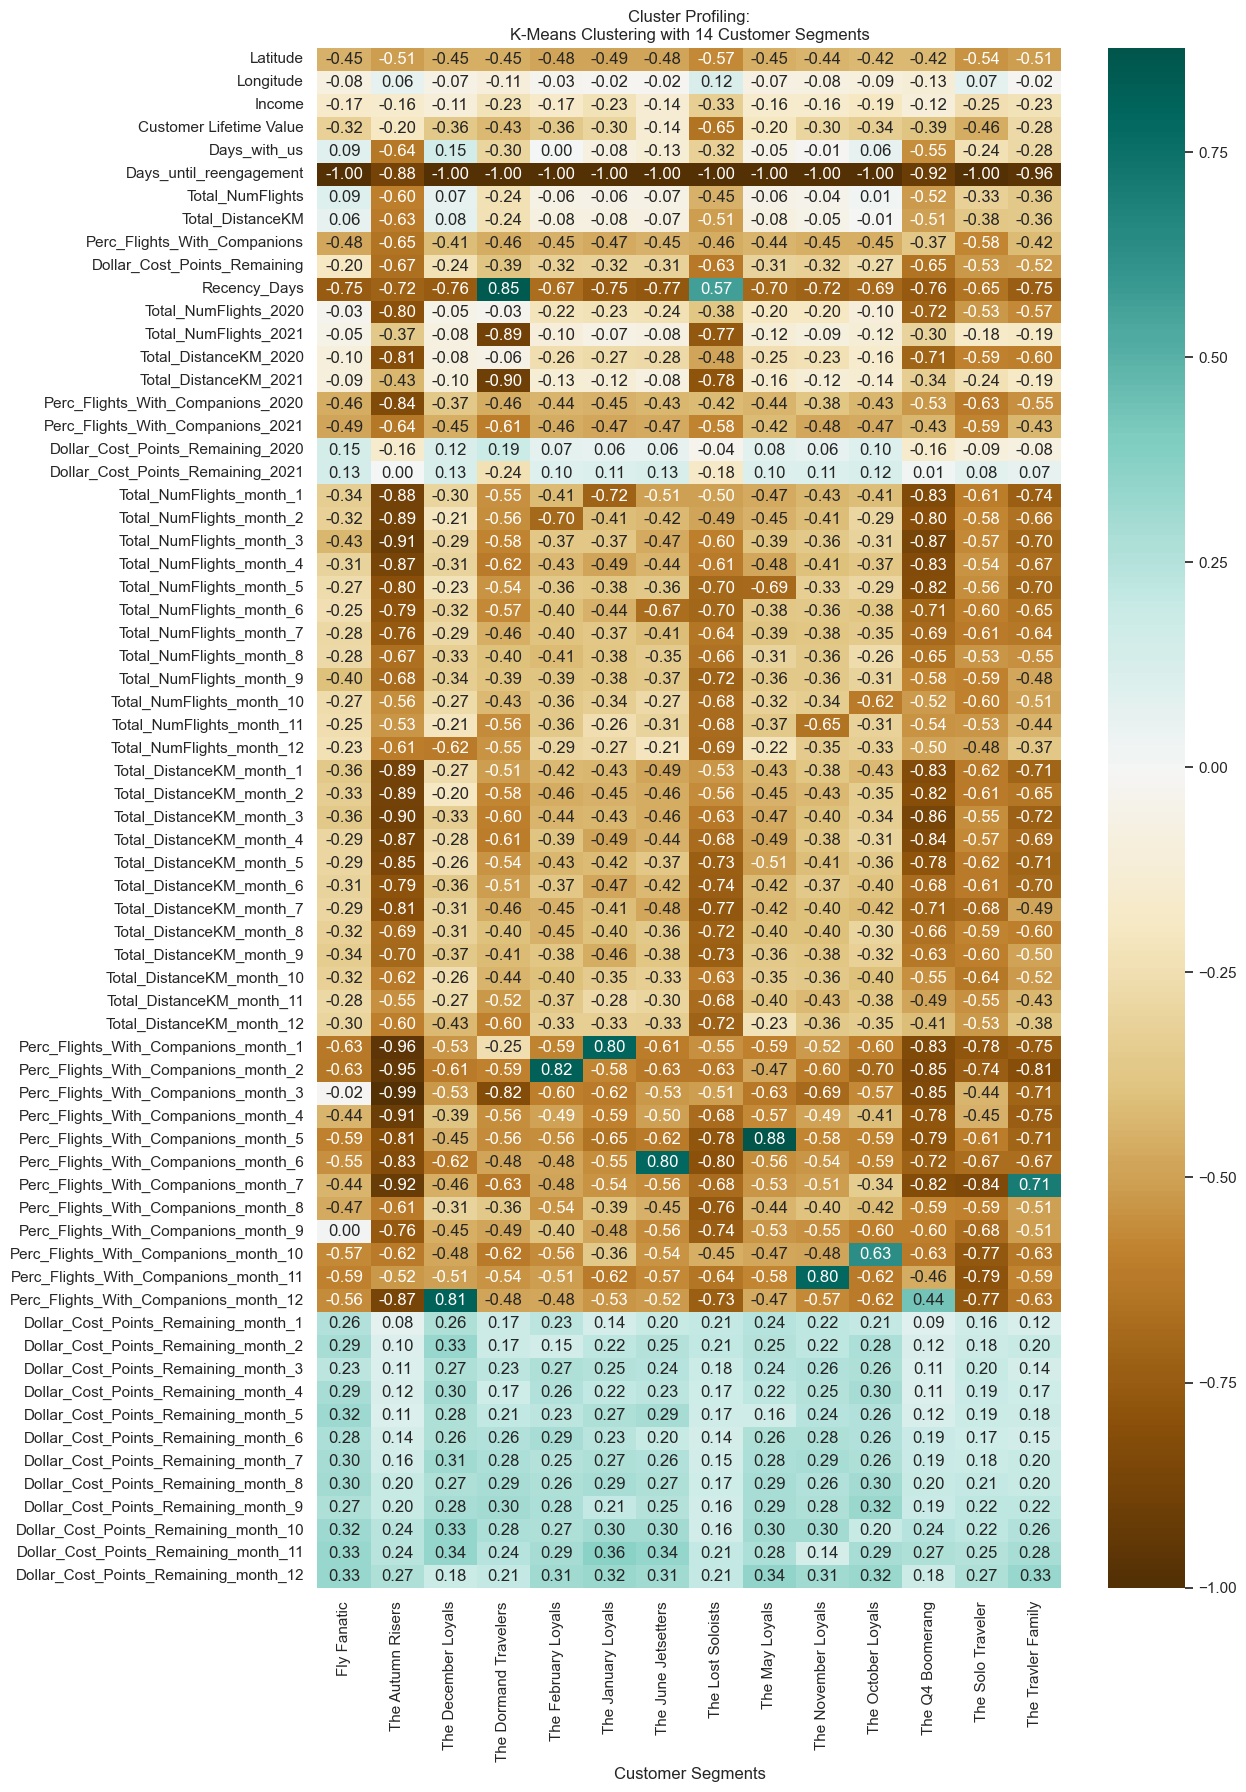

In [47]:
fig, ax = plt.subplots(figsize=(12, 20))

# Compute cluster profiles
km_profile = df_centroids.groupby('merged_labels').mean().T

# Rename cluster columns using your mapping

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nK-Means Clustering with 14 Customer Segments")
plt.show()

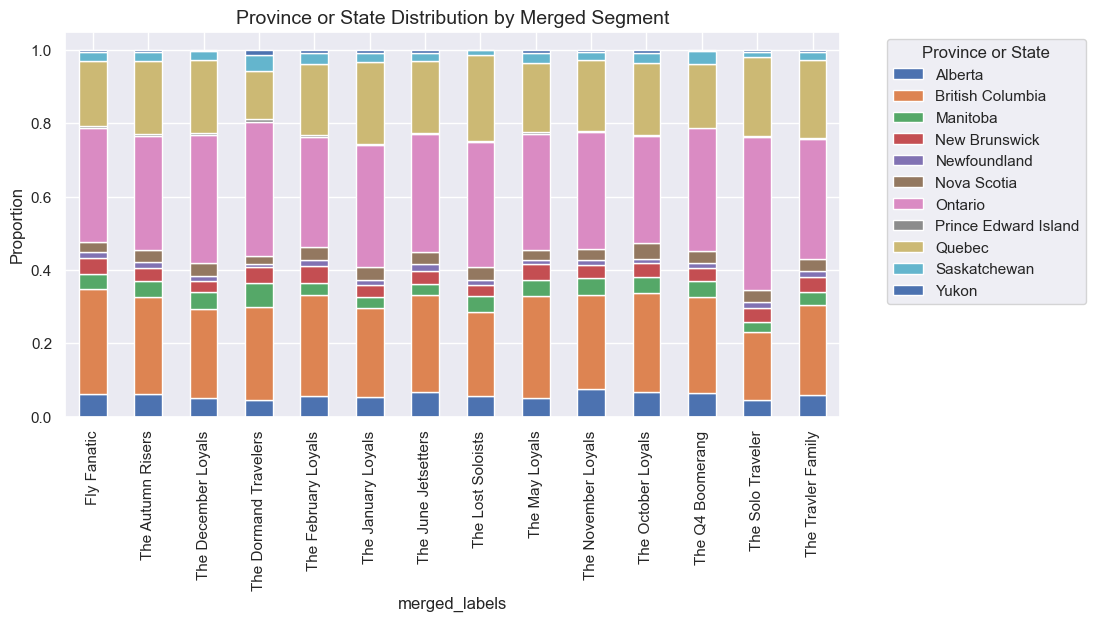

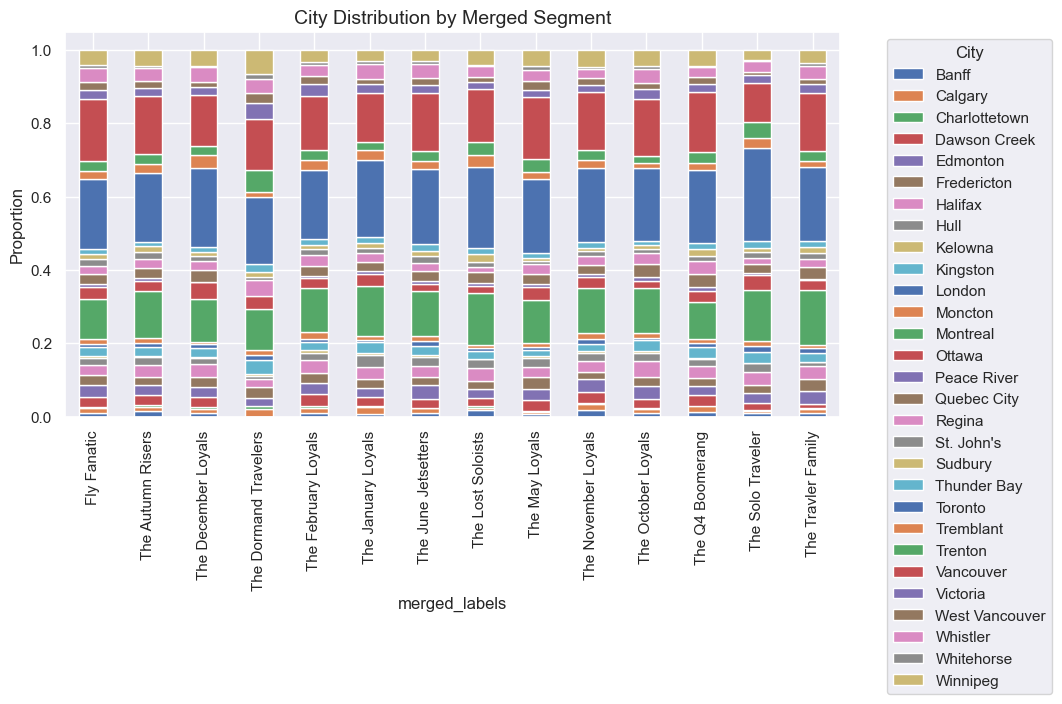

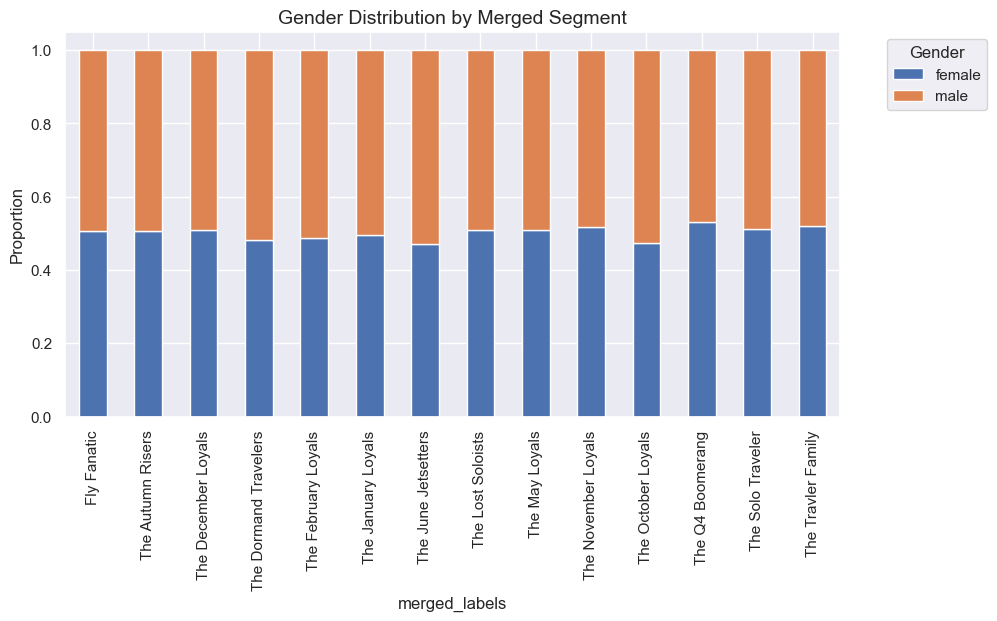

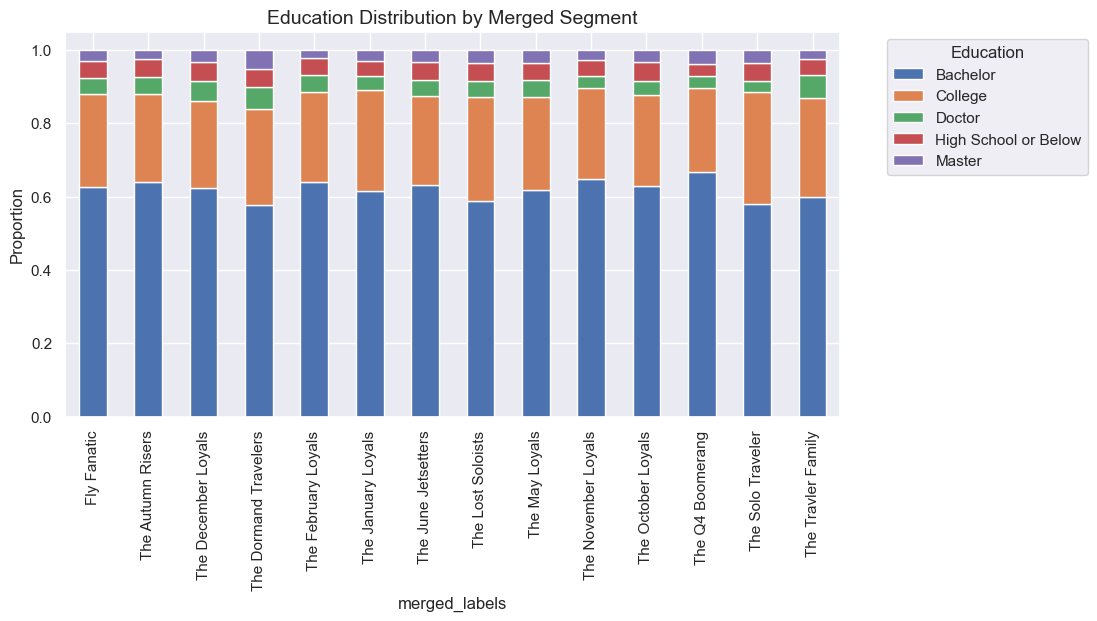

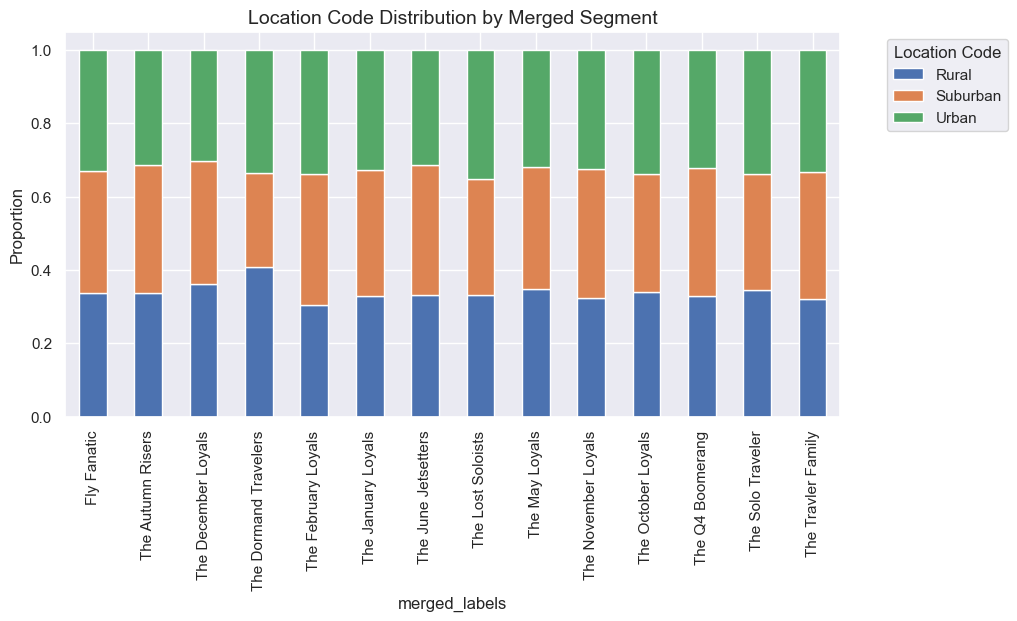

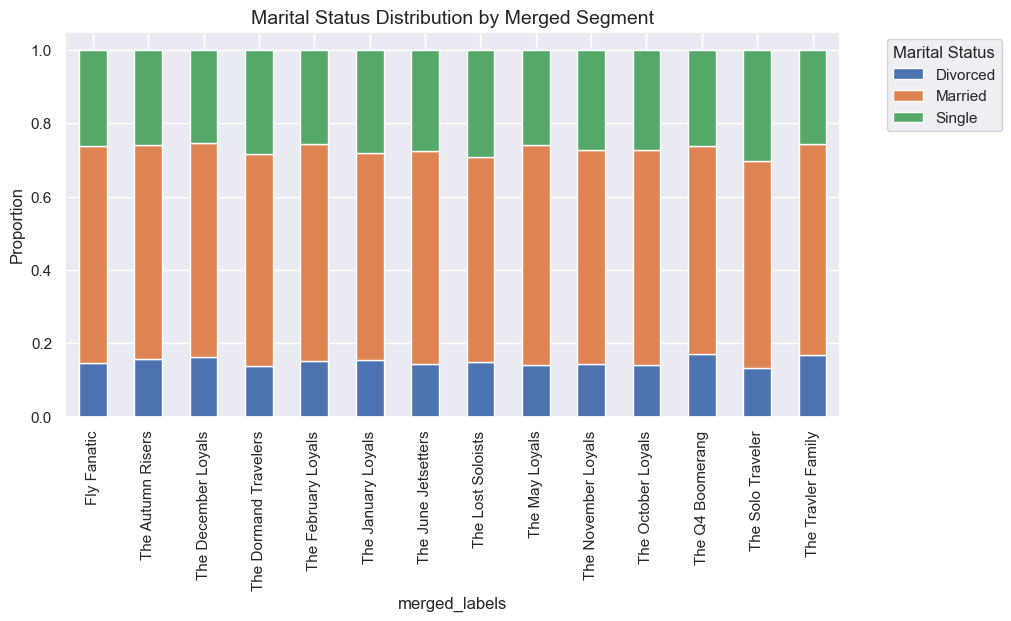

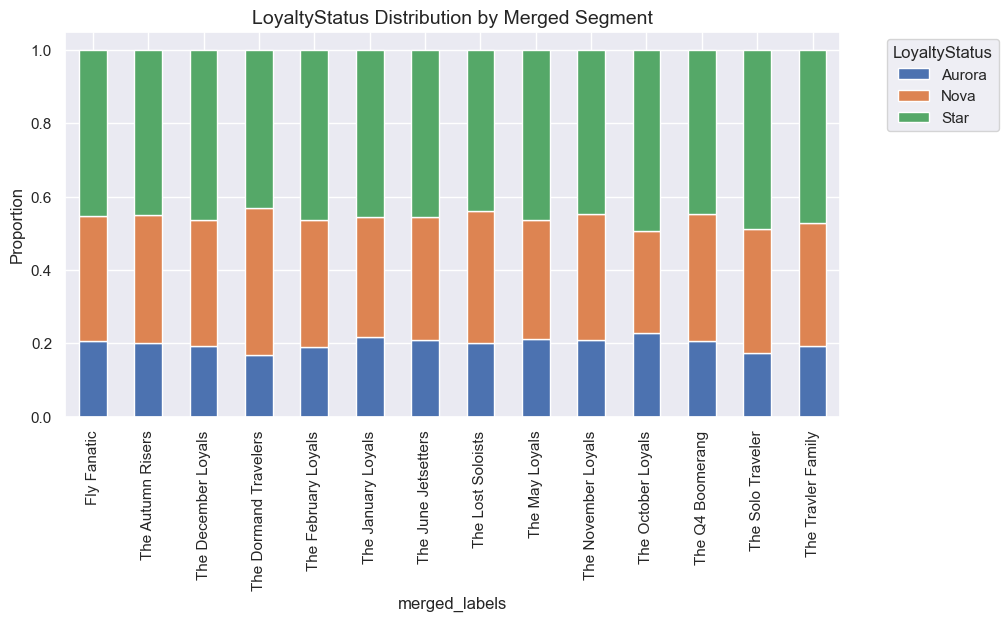

In [48]:
categorical = ['Province or State', 'City', 'Gender', 'Education',
               'Location Code', 'Marital Status', 'LoyaltyStatus']

for col in categorical:
    pd.crosstab(df_multi_perspective['merged_labels'],
                df_multi_perspective[col],
                normalize='index').plot.bar(
        stacked=True,
        figsize=(10, 5)
    )
    plt.title(f"{col} Distribution by Merged Segment", fontsize=14)
    plt.ylabel("Proportion")
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

**Profiling:**

First, we observe that longitude, latitude, and income lose much of their significance as they remain almost constant across all clusters, while the other variables used to build the clusters vary significantly depending on the group.

Regarding categorical variables, all clusters show the same proportions across different categories, meaning they do not provide additional discriminative value.

Here is the profiling for each cluster:

+ **The October Loyals (983):** Low revenue, long tenure. They have purchased recently, remain a consistent, engaged group over the years. These are "October people" who redeem points for companion travel in October.

+ **The Autumn Risers (2947):** Medium revenue, short tenure. Recently more active and traveling more now than before (moderately engaged). They are point redeemers and primarily autumn travelers.

+ **The June Jetsetters (999):** Medium revenue, moderate tenure. Recently active and traveling more now than before (very engaged). These are "June people" who redeem points for companion travel in June.

+ **The February Loyals (1063):** Low revenue, long tenure. Recently active and traveling more now than before (very engaged). These are "February people" who redeem points for companion travel in February.

+ **The November Loyals (1079):** Low revenue, long tenure. Recently active and traveling more now than before (very engaged). These are "November people" who redeem points for companion travel in November.

+ **The May Loyals (1061):** Medium revenue, long tenure. Recently active and traveling more now than before (very engaged). These are "May people" who redeem points for companion travel in May.

+ **The December Loyals (918):** Low revenue, long tenure. Very engaged, loyal customers. These are "December people" who redeem points for companion travel in December.

+ **The Dormand Travelers (137):** Low revenue, moderate tenure. These are lost customers who were active in 2019 and 2020 but stopped almost completely in 2021. They stay close to the average across all months.

+ **Fly Fanatic (3448):** Low revenue, long tenure. Very engaged, loyal customers. These are "March + September people" who redeem points for companion travel in March and September, but travel consistently across the year.

+ **The Travler Family (622):** Medium revenue, moderate tenure. Recently active and traveling more now than before (engaged). These are "July people" who redeem points for companion travel in July and travel in autumn.

+ **The January Loyals (1044):** Low revenue, long tenure. Recently active and traveling more now than before (very engaged). These are "January people" who redeem points for companion travel in March and January.

+ **The Solo Traveler (904):** Low revenue, moderate tenure. Recently active and traveling more now than before (engaged). They stay close to the average across all months and usually travel alone.

+ **The Q4 Boomerang (709):** Low revenue, short tenure. Recently active and traveling more now than before (moderately engaged). They are autumn travelers who travel with a companion in December.

+ **The Lost Soloists (658):** Low revenue, moderate tenure. These are lost customers who were moderately active in 2019 and 2020 but stopped almost completely in 2021. They stay below the average across all months and travel alone.

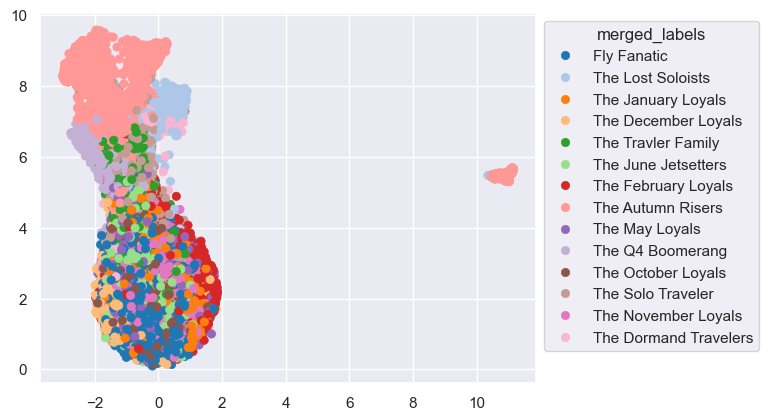

In [49]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(umap_for_modeling)
targets = df_multi_perspective['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

The same issue that occurred with hierarchical clustering is happening here.

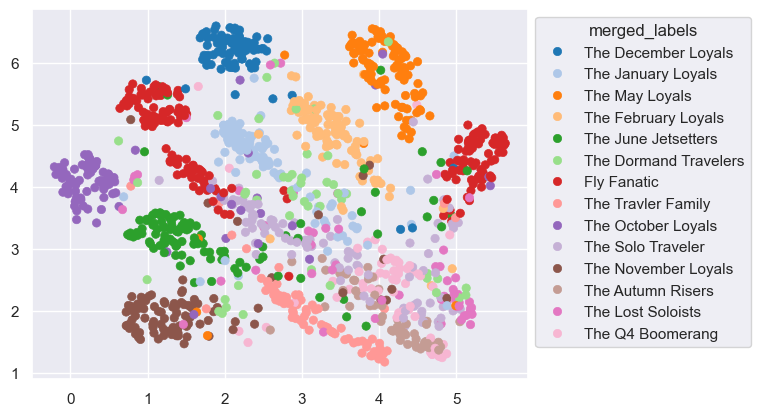

In [50]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(df_centroids.drop(columns=['merged_labels']))
targets = df_centroids['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Looking only at the centroids of our original features, we see that k_means clustering manages to split the customers, with some exceptions that tend to cluster together.

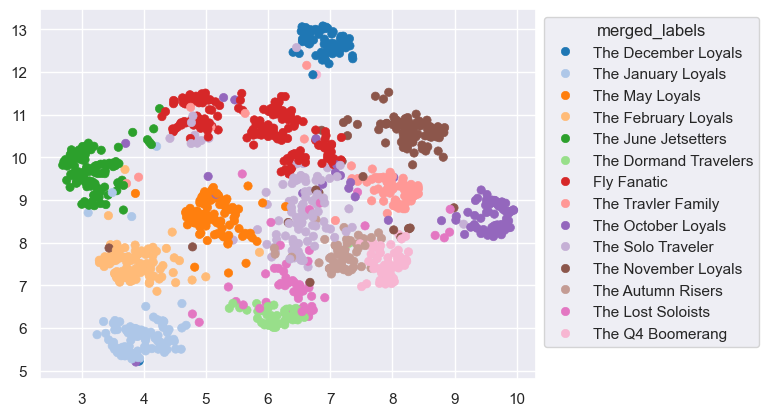

In [51]:
umap_original = umap.UMAP(n_neighbors = 100, random_state = 0).fit_transform(latent_vectors)
targets = df_centroids['merged_labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Looking only at the centroids of our latent features, we see that k-means clustering manages to split the customers, very well, meaining that our latent features actually improve the work of the cluster models.

In [52]:
X = umap_for_modeling.values

# Computing SST
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

# Computing SSW
ssw_iter = []                   # Outer summation
for i in np.unique(df_multi_perspective['merged_labels']):  # Loop for inner summation
    X_k = X[df_multi_perspective['merged_labels'] == i]     # Data points belonging to cluster k
    inner_sum = np.sum(np.square(X_k - X_k.mean(axis=0)), axis=0)
    ssw_iter.append(inner_sum)
ssw_per_feature = np.sum(ssw_iter, axis=0)  # Outer summation
ssw = np.sum(ssw_per_feature, axis=0)

# Computing SSB
ssb_iter = []
for i in np.unique(df_multi_perspective['merged_labels']):  # Loop for summation
    X_k = X[df_multi_perspective['merged_labels'] == i]     # Data points belonging to cluster k
    ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))

ssb_per_feature = np.sum(ssb_iter, axis=0)
ssb = np.sum(ssb_per_feature, axis=0)

In [53]:
sil_km = silhouette_score(X, df_multi_perspective['merged_labels'])

km_row = pd.DataFrame([{
    'num_clusters': len(np.unique(df_multi_perspective['merged_labels'])),
    'ssw (Lower is better, 0 to +∞)': ssw,
    'ssb (Higher is better, 0 to SST)': ssb,
    'silhouette_score (Higher is better, −1 to +1)': sil_km,
    'r2 (Higher is better, 0 to 1)': ssb / sst,
    'Method': 'K-Means'
}])

column_order = [
    'Method',
    'num_clusters',
    'r2 (Higher is better, 0 to 1)',
    'silhouette_score (Higher is better, −1 to +1)',
    'ssw (Lower is better, 0 to +∞)',
    'ssb (Higher is better, 0 to SST)'
]

km_row = km_row[column_order]

display(km_row)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,K-Means,14,0.29434,0.064566,175141.594595,73053.697048


## <a id='toc1_12_'></a>[C-Means](#toc0_)

Now that we see some clusters exhibit similar behavior and some observations are mixed, we are going to test a soft clustering technique, specifically Fuzzy C-Means.

We will start by analising different fuzziness and number of clusters.

In [54]:
# --- CONFIGURATION ---
# Range of clusters to test
c_range = range(2, 20)  # Test 2 to 10 clusters

# Range of fuzziness to test (standard is usually 1.5 to 2.5)
# m=1.1 is very hard (like K-Means), m=3.0 is very fuzzy
m_range = np.linspace(1.1, 2.0, 10)

# Data setup (Expects features x samples)
data = latent_vectors.T

# Storage for results
results = []

print("Starting Grid Search for C and M...")

# --- THE GRID SEARCH LOOP ---
for c in c_range:
    for m in m_range:
        # Run FCM
        # error=0.005 and maxiter=1000 ensures convergence
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            data, c, m, error=0.005, maxiter=1000, init=None
        )

        # Calculate Fuzzy Partition Entropy (FPE) manually
        # FPE = -Sum(u * log(u)) / N
        n_samples = u.shape[1]
        fpe = -np.sum(u * np.log(u + 1e-10)) / n_samples

        results.append({
            'Clusters (c)': c,
            'Fuzziness (m)': round(m, 2),
            'FPC (Higher is Better)': fpc,
            'FPE (Lower is Better)': fpe
        })

# Convert to DataFrame
results_df = pd.DataFrame(results)


Starting Grid Search for C and M...


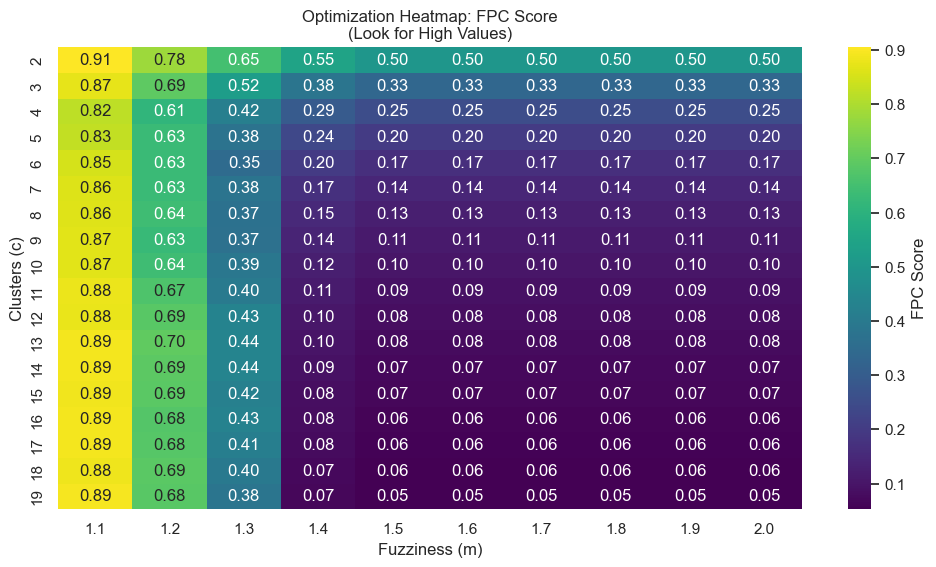

In [55]:
# --- VISUALIZATION 1: The Heatmap (Interaction of C and M) ---
# We pivot the data to create a matrix for the heatmap
heatmap_data = results_df.pivot(index='Clusters (c)', columns='Fuzziness (m)', values='FPC (Higher is Better)')

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'FPC Score'})
plt.title('Optimization Heatmap: FPC Score\n(Look for High Values)')
plt.show()

We see that the FPC score (Fuzzy Partition Coefficient), which ranges between 0 and 1, decreased as the fuzziness increased; this indicates that our clusters might not be as fuzzy as we initially thought. For that reason we are going to use the fuzzines of 1.1 (that is a very close to a hard cluster).

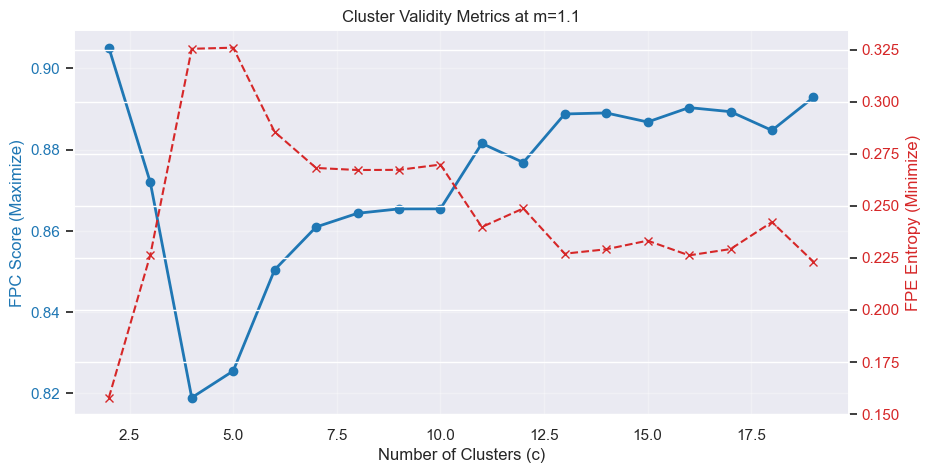

In [56]:
# --- VISUALIZATION 2: The Elbow Curve
m_target = results_df['Fuzziness (m)'].unique()
# Find closest to 1.1
m_standard = m_target[np.abs(m_target - 1.1).argmin()]

subset = results_df[results_df['Fuzziness (m)'] == m_standard]

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (c)')
ax1.set_ylabel('FPC Score (Maximize)', color=color)
ax1.plot(subset['Clusters (c)'], subset['FPC (Higher is Better)'], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('FPE Entropy (Minimize)', color=color)
ax2.plot(subset['Clusters (c)'], subset['FPE (Lower is Better)'], marker='x', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Cluster Validity Metrics at m={m_standard}')
plt.show()

After seeing the entropy and FPC score for a fuzziness of 1.1, we see that the best value for both components occurs when c = 15; for that reason, we are going to group the data into 15 clusters.

In [57]:
# --- STEP 2: Run Fuzzy C-Means ---
n_clusters = 15   # Number of segments you want
m_parameter = 1.1 # Fuzziness coefficient

print(f"Running Fuzzy C-Means with k={n_clusters}...")
# cntr: centers, u: membership matrix, fpc: fuzzy partition coefficient (quality metric)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data,
    c=n_clusters,
    m=m_parameter,
    error=0.005,
    maxiter=1000,
    init=None
)

print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
# FPC ranges 0 to 1. Closer to 1 = Crisp/Clean clustering. Closer to 0 = Very fuzzy.

Running Fuzzy C-Means with k=15...
Fuzzy Partition Coefficient (FPC): 0.8887


Now we will create a hard clustering label by selecting the maximum probability value for each cluster and then analyze the level of certainty associated with each assignment.

In [58]:
# --- STEP 3: Membership Degree Analysis (CORRECTED) ---
# Create the dataframe from the fuzzy matrix 'u'
membership_df = pd.DataFrame(u.T, columns=[f'Prob_Cluster_{i}' for i in range(n_clusters)])

# --- FIX START ---
# 1. Calculate Max Confidence FIRST, using only the probability columns
# We filter only columns starting with 'Prob_' to be safe
prob_cols = [c for c in membership_df.columns if 'Prob_' in c]
membership_df['Max_Confidence'] = membership_df[prob_cols].max(axis=1)

# 2. THEN calculate the Hard Label
membership_df['Hard_Label'] = membership_df[prob_cols].idxmax(axis=1).str.extract(r'(\d+)').astype(int)

print("\nSample Membership Analysis (First 5 rows):")
print(membership_df[['Hard_Label', 'Max_Confidence']].head())


Sample Membership Analysis (First 5 rows):
   Hard_Label  Max_Confidence
0          10        0.999999
1           9        0.590263
2           5        0.860446
3          10        0.999991
4          10        0.999994


And now we will establish a threshold: when we are at least 70% certain of a cluster assignment, it will be classified as a core point; if certainty is less than 50%, it will be classified as fuzzy (not clear); and if it falls in the middle, it will be marked for further analysis.

In [59]:
# --- STEP 4: Compare Soft vs Hard (Core vs Bridge Analysis) ---
# We define "Core" customers as those with >70% probability of belonging to a cluster
# We define "Bridge" customers as those with <50% probability (highly mixed behavior)

threshold_core = 0.70
threshold_bridge = 0.50

membership_df['Segment_Type'] = pd.cut(
    membership_df['Max_Confidence'],
    bins=[0, threshold_bridge, threshold_core, 1.0],
    labels=['Bridge (Fuzzy)', 'Standard', 'Core (Crisp)']
)

print("\n--- Hard vs Soft Clustering Distribution ---")
print(membership_df['Segment_Type'].value_counts(normalize=True))


--- Hard vs Soft Clustering Distribution ---
Segment_Type
Core (Crisp)      0.893250
Standard          0.069074
Bridge (Fuzzy)    0.037677
Name: proportion, dtype: float64


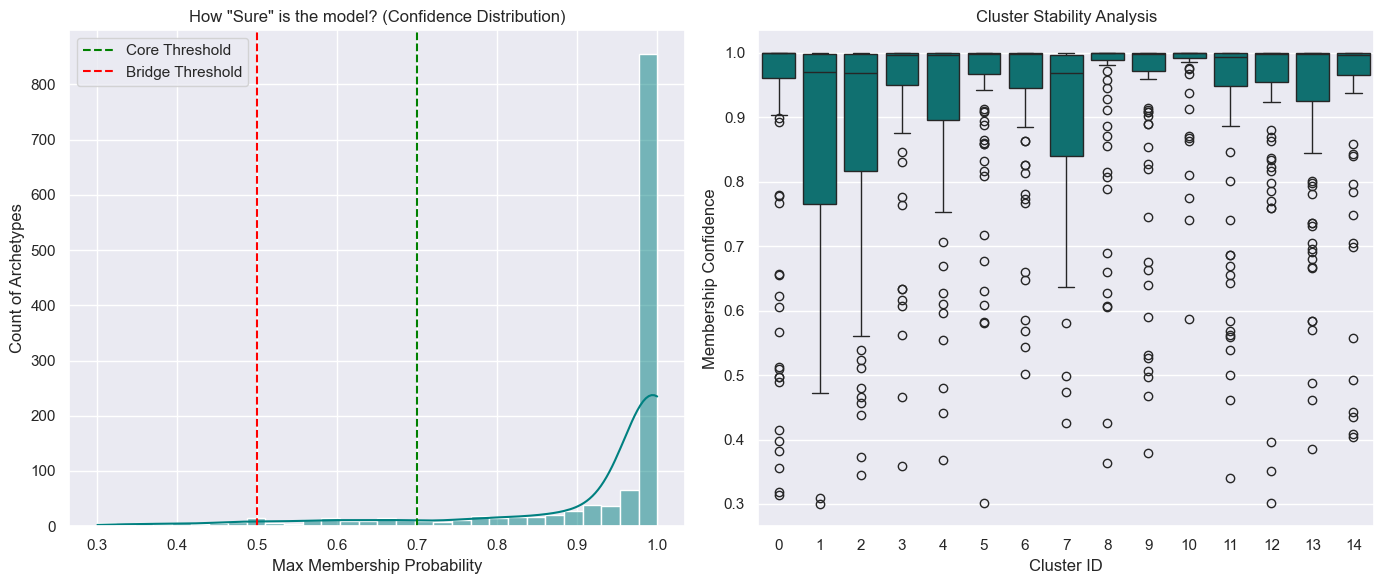

In [60]:
# --- STEP 5: Visualizing Customer Overlap ---
plt.figure(figsize=(14, 6))

# Plot 1: Histogram of Confidence
# If this skews Right (towards 1.0), your clusters are distinct.
# If this skews Left (towards 0.3), your clusters are very overlapping.
plt.subplot(1, 2, 1)
sns.histplot(membership_df['Max_Confidence'], bins=30, kde=True, color='teal')
plt.axvline(x=threshold_core, color='green', linestyle='--', label='Core Threshold')
plt.axvline(x=threshold_bridge, color='red', linestyle='--', label='Bridge Threshold')
plt.title('How "Sure" is the model? (Confidence Distribution)')
plt.xlabel('Max Membership Probability')
plt.ylabel('Count of Archetypes')
plt.legend()

# Plot 2: Ambiguity per Cluster
# Which cluster is the most distinct vs. which one captures the "Leftovers"?
plt.subplot(1, 2, 2)
sns.boxplot(x='Hard_Label', y='Max_Confidence', data=membership_df, color='teal')
plt.title('Cluster Stability Analysis')
plt.xlabel('Cluster ID')
plt.ylabel('Membership Confidence')

plt.tight_layout()
plt.show()



In [61]:
membership_df['Segment_Type'].value_counts()

Segment_Type
Core (Crisp)      1138
Standard            88
Bridge (Fuzzy)      48
Name: count, dtype: int64

We see that on the majority of clusters more than 75% of the combined labels are classified with certaininty. With only 46 that are fuzzy.

In [62]:
# --- STEP 6: Extracting "Standard" Archetypes ---
# These are the most interesting business cases: People who sit between two worlds.
print("\n--- Analysis of 'Standard' Customers (Some Overlap) ---")
bridge_customers = membership_df[membership_df['Segment_Type'] == 'Standard'].copy()

if not bridge_customers.empty:
    # Find the top 2 competing clusters for these bridge users
    def get_top_two(row):
        cols = [c for c in membership_df.columns if 'Prob_' in c]
        # Explicitly cast to float to ensure nlargest works correctly
        top2 = row[cols].astype(float).nlargest(2).index.tolist()
        return f"{top2[0]} vs {top2[1]}"

    bridge_customers['Conflict_Between'] = bridge_customers.apply(get_top_two, axis=1)

    print("Most common conflicts (Which segments overlap the most?):")
    display(bridge_customers['Conflict_Between'].value_counts().head(12))
else:
    print("No bridge customers found (Clusters are very separated).")


--- Analysis of 'Standard' Customers (Some Overlap) ---
Most common conflicts (Which segments overlap the most?):


Conflict_Between
Prob_Cluster_1 vs Prob_Cluster_5      5
Prob_Cluster_1 vs Prob_Cluster_2      4
Prob_Cluster_11 vs Prob_Cluster_2     3
Prob_Cluster_6 vs Prob_Cluster_8      3
Prob_Cluster_2 vs Prob_Cluster_11     3
Prob_Cluster_4 vs Prob_Cluster_1      3
Prob_Cluster_11 vs Prob_Cluster_13    3
Prob_Cluster_1 vs Prob_Cluster_4      3
Prob_Cluster_0 vs Prob_Cluster_13     3
Prob_Cluster_11 vs Prob_Cluster_3     2
Prob_Cluster_13 vs Prob_Cluster_0     2
Prob_Cluster_0 vs Prob_Cluster_3      2
Name: count, dtype: int64

Here we see that cluster 8 and 6 overlap slightly, as do clusters 11 and 4, and 6 and 11; the remaining clusters only overlap in a few specific categories.

Now we will give the respective label to each of the customer to analyse them.

In [63]:
membership_df['Combo_ID'] = df_centroids.index.map(lambda x: '_'.join(map(str, x)))

# --- STEP 2: Merge Probabilities into the Main Customer Table ---
# df_multi_perspective (15k rows) <--- JOIN ---> membership_df (1274 rows)

# If using Option A (Combo_ID):
# Ensure df_multi_perspective has the same Combo_ID column
if 'Combo_ID' not in df_multi_perspective.columns:
    # Re-create it if missing (adjust column names to yours)
    cols = ['Demographic_Cluster_Name', 'Behavioral_Year_Cluster_Name',
            'Behavioral_Month_Cluster_Name', 'Value_Based_Cluster_Name']
    df_multi_perspective['Combo_ID'] = df_multi_perspective[cols].astype(str).agg('_'.join, axis=1)


# Perform the Merge
df_reset = df_multi_perspective.reset_index()

action_df = df_reset.merge(
    membership_df,
    on='Combo_ID',
    how='left'
)

action_df.set_index('Loyalty#', inplace=True)

# --- STEP 3: Verify the Join ---
print(f"Original Customer Count: {len(df_multi_perspective)}")
print(f"Action DF Count: {len(action_df)}")
# These two numbers MUST match. If Action DF is bigger, you have duplicates in membership_df.


Original Customer Count: 16572
Action DF Count: 16572


In [64]:
action_df[['Segment_Type']].value_counts()

Segment_Type  
Core (Crisp)      16048
Standard            441
Bridge (Fuzzy)       83
Name: count, dtype: int64

In [65]:
action_df[['Segment_Type']].value_counts()

Segment_Type  
Core (Crisp)      16048
Standard            441
Bridge (Fuzzy)       83
Name: count, dtype: int64

We see that the majority of customers have a confident label, 105 are very unclear and 299 are a misture of clusters.

Now we will see the number of customers assigned to each of the clusters.

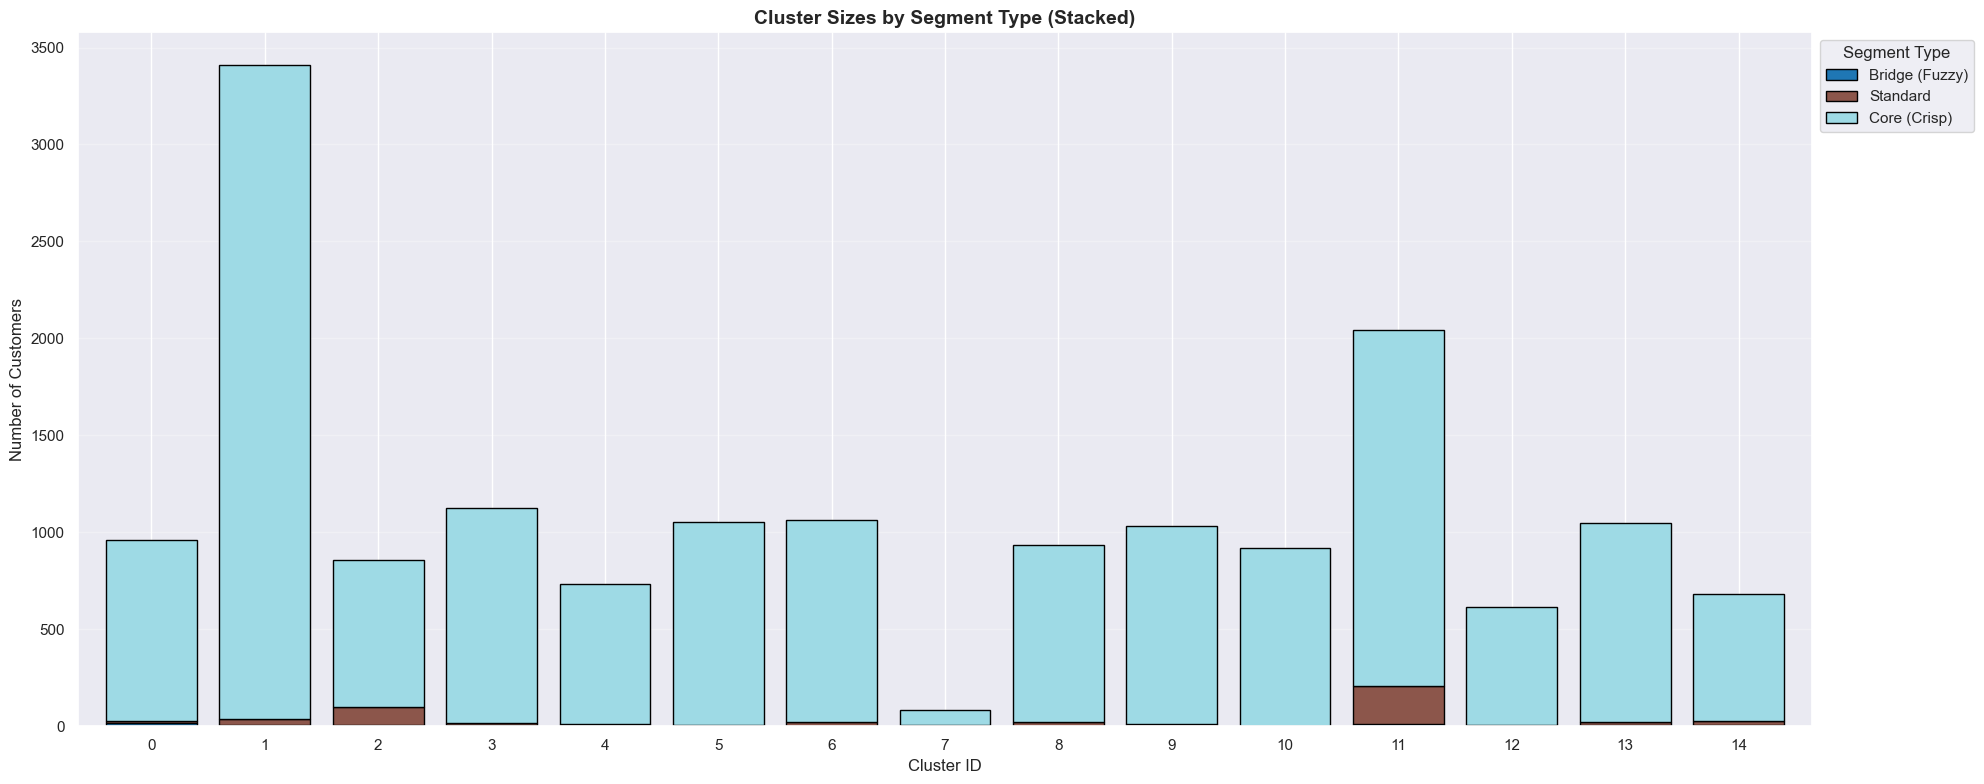

In [66]:
cluster_composition = pd.crosstab(action_df['Hard_Label'], action_df['Segment_Type'])

# --- STEP 2: Plotting ---
fig, ax2 = plt.subplots(1, figsize=(20, 8))

# Use the pandas plot integration for easy stacking
cluster_composition.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    colormap='tab20', # Good colors for categorical distinctions
    edgecolor='black',  # Adds a nice border to segments
    width=0.8
)

# --- STEP 3: Formatting ---
ax2.set_xlabel('Cluster ID', fontsize=12)
ax2.set_ylabel('Number of Customers', fontsize=12)
ax2.set_title('Cluster Sizes by Segment Type (Stacked)', fontsize=14, fontweight='bold')

# Rotate x-labels if they are simple numbers
ax2.set_xticklabels(cluster_composition.index, rotation=0)

ax2.grid(axis='y', alpha=0.3)
ax2.legend(title='Segment Type', bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.tight_layout()
plt.show()

In [67]:
action_df.head()

,Province or State,City,Latitude,Longitude,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,Days_with_us,Days_until_reengagement,Total_NumFlights,Total_DistanceKM,Perc_Flights_With_Companions,Dollar_Cost_Points_Remaining,Recency_Days,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12,Demographic_Cluster_Name,Behavioral_Year_Cluster_Name,Behavioral_Month_Cluster_Name,Value_Based_Cluster_Name,merged_labels,Combo_ID,Prob_Cluster_0,Prob_Cluster_1,Prob_Cluster_2,Prob_Cluster_3,Prob_Cluster_4,Prob_Cluster_5,Prob_Cluster_6,Prob_Cluster_7,Prob_Cluster_8,Prob_Cluster_9,Prob_Cluster_10,Prob_Cluster_11,Prob_Cluster_12,Prob_Cluster_13,Prob_Cluster_14,Max_Confidence,Hard_Label,Segment_Type
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,Urban,70146.0,Married,Star,3839.14,1049,0.0,191.0,497375.0,29.319372,362.1394,29.0,64.0,68.0,128976.0,252320.0,29.687500,29.411765,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610,High-Income East,Stable average travelers\r\n(Loyal),Avr|Mar Companion\n(Less travel on mar),Fly fanatics,Fly Fanatic,High-Income East_Stable average travelers\r\n(...,4.043476e-06,5.323969e-09,0.000003,9.962153e-01,8.480243e-09,2.348503e-06,0.000001,8.383853e-09,3.713743e-05,1.827008e-07,3.556133e-05,0.003700,3.377406e-07,5.773235e-07,2.754044e-10,0.996215,3,Core (Crisp)
549612,Alberta,Edmonton,53.544388,-113.490930,male,College,Rural,0.0,Divorced,Star,3839.61,1027,0.0,279.0,389939.0,11.469534,165.2639,29.0,99.0,91.0,142191.0,119776.0,8.080808,18.681319,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-142.9017,76.7735,24.3200,33.6881,35.8801,27.15

And see how the clear customer behave.

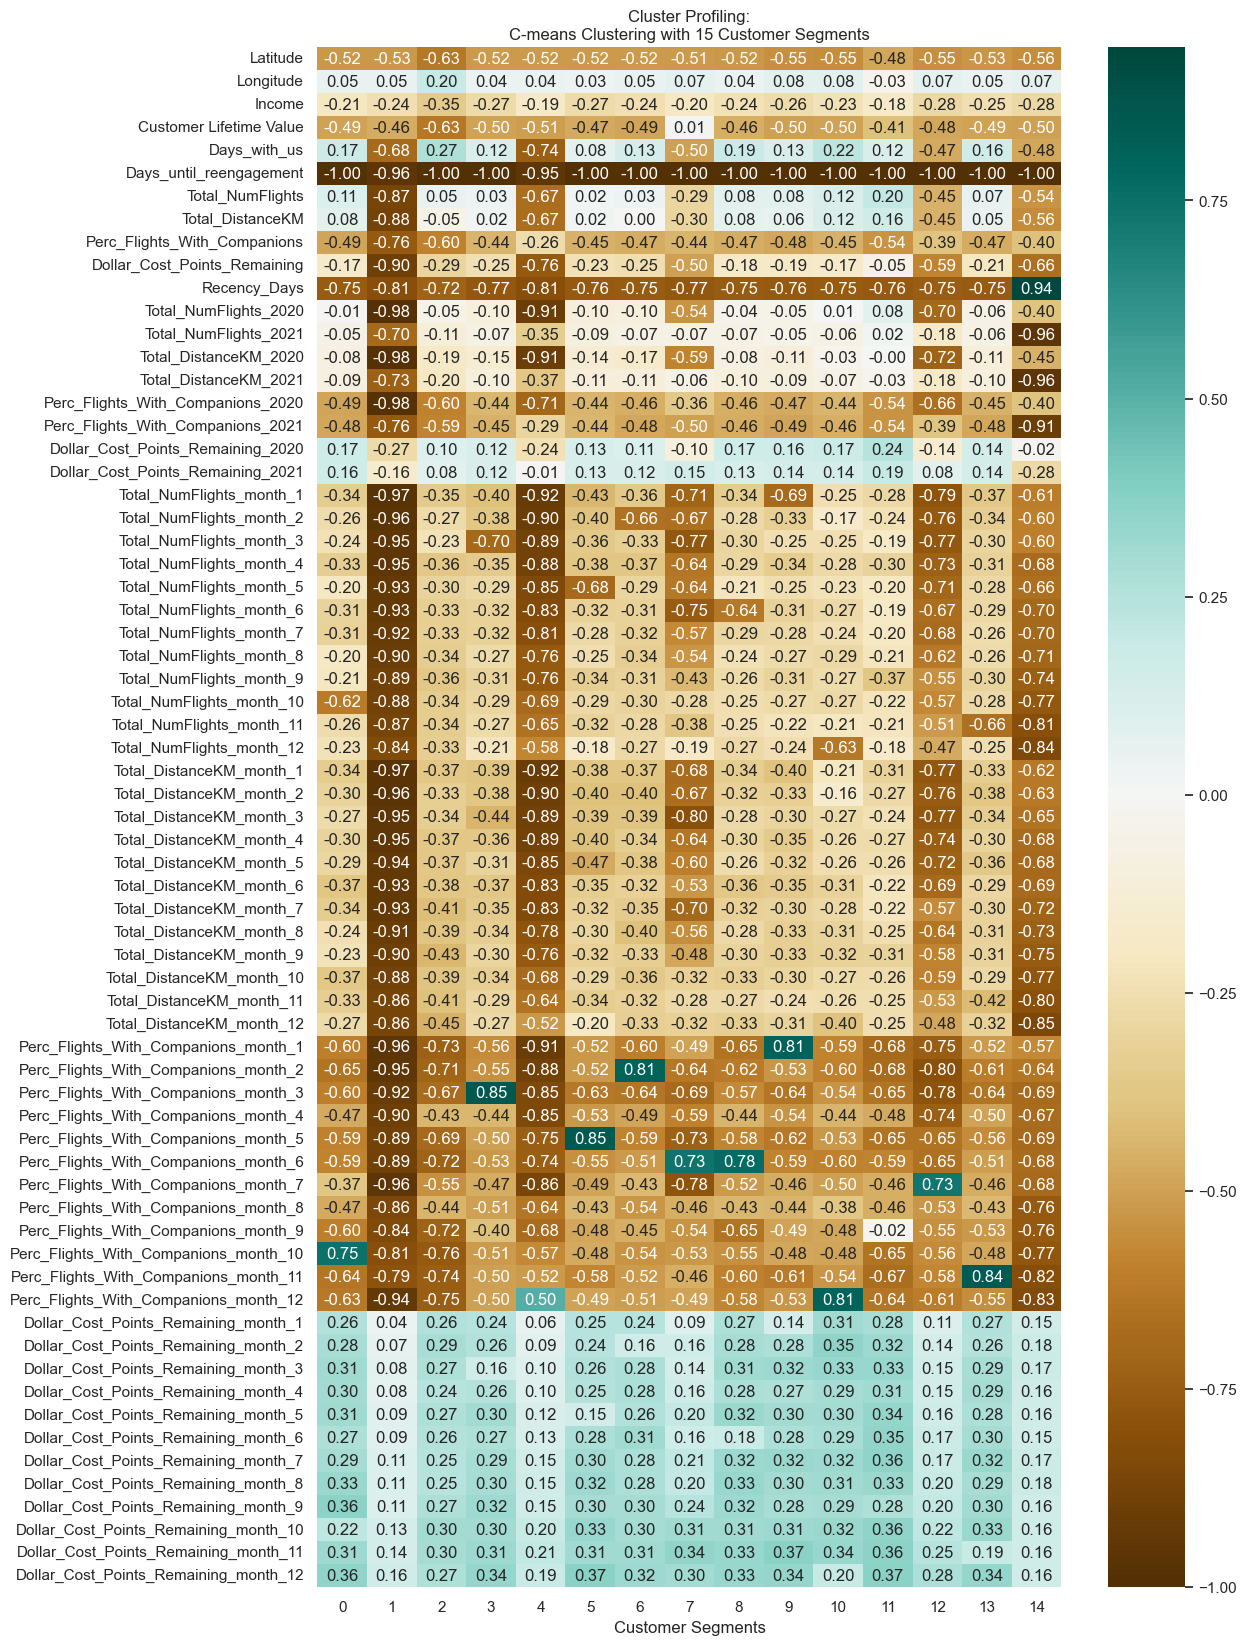

In [68]:
fig, ax = plt.subplots(figsize=(12, 20))

# 1. Filter for Core customers only
temp = umap_for_modeling.copy()
temp['Hard_Label'] = action_df['Hard_Label']
core_customers = temp[action_df['Segment_Type'] == 'Core (Crisp)']

# 2. Group by Cluster ID (Hard_Label)
# You can then chain .mean(), .count(), or .size() depending on what you need
cm_profile = core_customers.groupby('Hard_Label').mean().T

# Rename cluster columns using your mapping

sns.heatmap(
    cm_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nC-means Clustering with 15 Customer Segments")
plt.show()

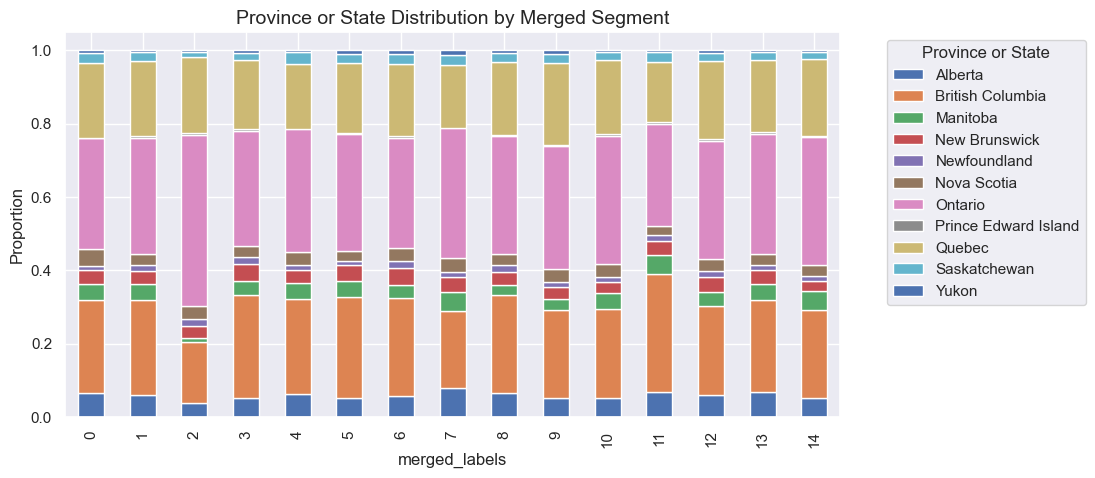

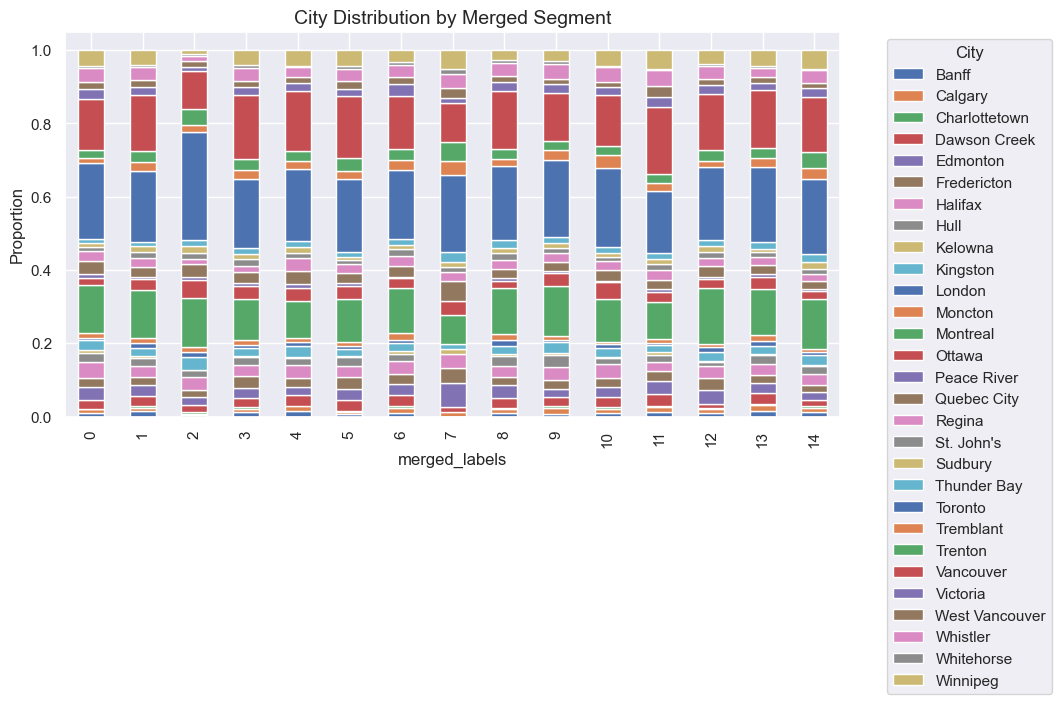

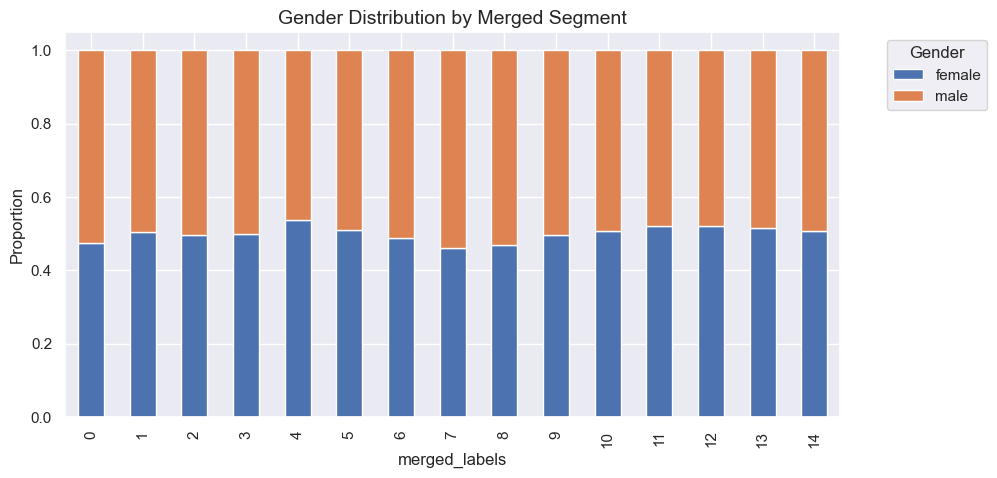

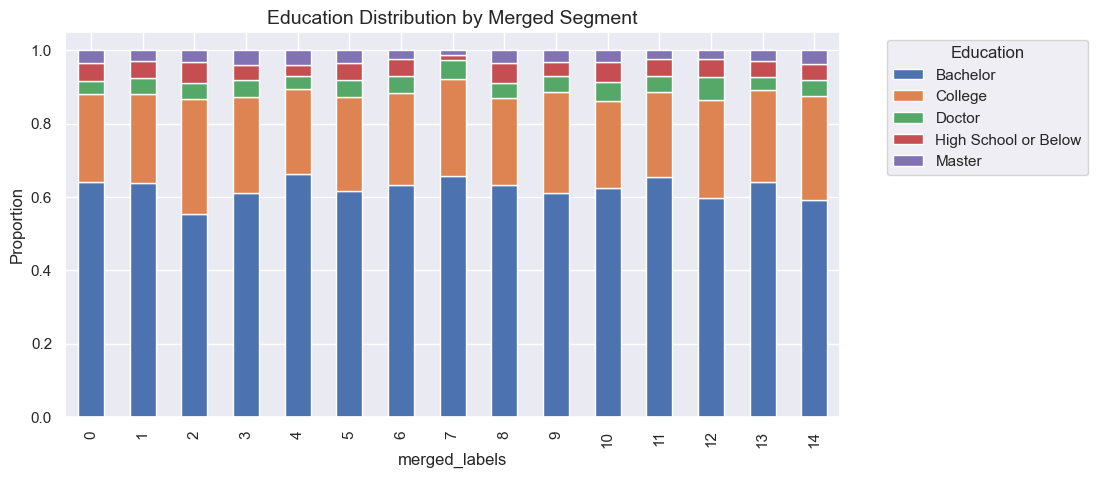

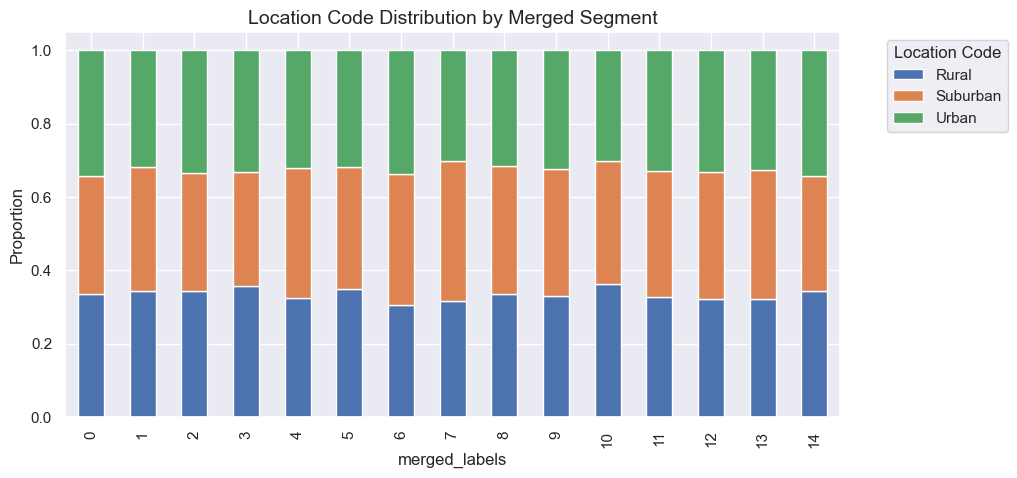

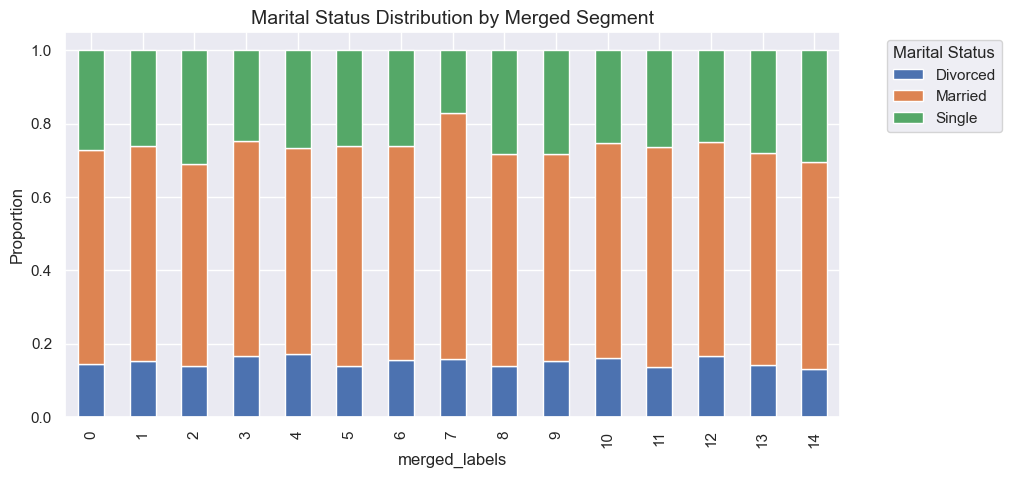

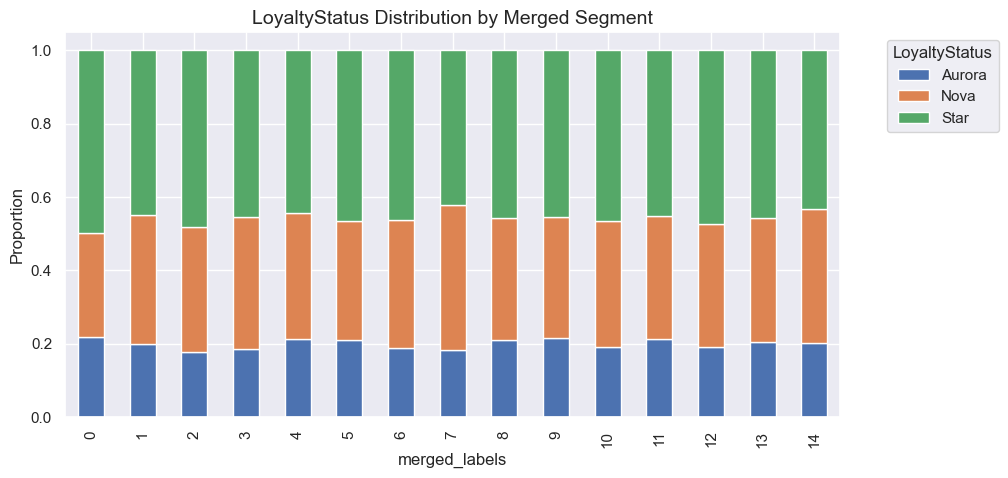

In [69]:
categorical = ['Province or State', 'City', 'Gender', 'Education',
               'Location Code', 'Marital Status', 'LoyaltyStatus']

temp = df_multi_perspective.copy()
temp['merged_labels'] = action_df['Hard_Label']
core_customers_cat = temp[action_df['Segment_Type'] == 'Core (Crisp)']

for col in categorical:
    pd.crosstab(core_customers_cat['merged_labels'],
                core_customers_cat[col],
                normalize='index').plot.bar(
        stacked=True,
        figsize=(10, 5)
    )
    plt.title(f"{col} Distribution by Merged Segment", fontsize=14)
    plt.ylabel("Proportion")
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

**Profiling**

For customers categorized as fuzzy, we recommend not assigning them to a specific cluster, as they can be considered outliers or simply do not exhibit a clear enough pattern for reliable targeting. For standard customers, we will perform at the end a secondary analysis to determine if a multi-label approach is necessary, as their behavior suggests they belong to two or more distinct groups, but only if we see that this is our best solution.

General Observations: Variables such as longitude, latitude, days until re-engagement, CLV, and income remain almost constant across all groups, losing their discriminative power. Similarly, categorical variables show identical proportions across all clusters, providing no additional value for segmentation.

Well-Defined Cluster Profiles:

+ **Cluster 0 (714 Core, 10 Standard, 1 Fuzzy):** Short tenure. Recently active and moderately engaged. These are point redeemers and primarily autumn travelers who fly with companions in December.

+ **Cluster 1 (914 Core, 20 Standard, 3 Fuzzy):** Long tenure; very engaged and loyal. These are "June people" who specifically redeem points for companion travel in June.

+ **Cluster 2 (1112 Core, 10 Standard, 5 Fuzzy):** Long tenure; very engaged and loyal. These are "March people" who prioritize redeeming points for companion travel in March.

+ **Cluster 3 (1031 Core, 17 Standard, 6 Fuzzy):** Long tenure; very engaged and loyal. These are "November people" who redeem points for companion travel in November.

+ **Cluster 4 (2708 Core, 32 Standard, 18 Fuzzy):** Long tenure; very engaged and loyal. They accumulate points and typically travel alone with high consistency across months and years.

+ **Cluster 5 (1047 Core, 28 Standard, 1 Fuzzy):** Long tenure; very engaged and loyal. These are "February people" who redeem points for companion travel in February.

+ **Cluster 6 (1018 Core, 9 Standard, 2 Fuzzy):** Long tenure; very engaged and loyal. These are "January people" who redeem points for companion travel in January.

+ **Cluster 7 (572 Core, 16 Standard, 4 Fuzzy):** Short transaction history. Inactive for a long period; previously more active, now considered "at risk" or lost.

+ **Cluster 8 (1048 Core, 6 Standard, 2 Fuzzy):** Long tenure; very engaged and loyal. These are "May people" who redeem points for companion travel in May.

+ **Cluster 9 (609 Core, 2 Standard, 15 Fuzzy):** Moderate tenure. "New loyal" customers who increased activity in 2021. They enjoy autumn travel, point usage, and companion travel in July.

+ **Cluster 10 (940 Core, 14 Standard, 5 Fuzzy):** Long tenure; very engaged and loyal. These are "October people" who redeem points for companion travel in October.

+ **Cluster 11 (205 Core, 3 Standard, 2 Fuzzy):** Moderate tenure. Formerly high-frequency travelers who have since become inactive.

+ **Cluster 12 (78 Core, 4 Standard, 1 Fuzzy):** High revenue, short tenure. VIP customers whose travel increased in 2021 compared to previous years; they fly with companions in June.

+ **Cluster 13 (3378 Core, 28 Standard, 14 Fuzzy):** New customers with very short transaction records.

+ **Cluster 14 (917 Core, 3 Standard, 0 Fuzzy):** Long tenure; very engaged and loyal. These are "December people" who redeem points for companion travel in December.

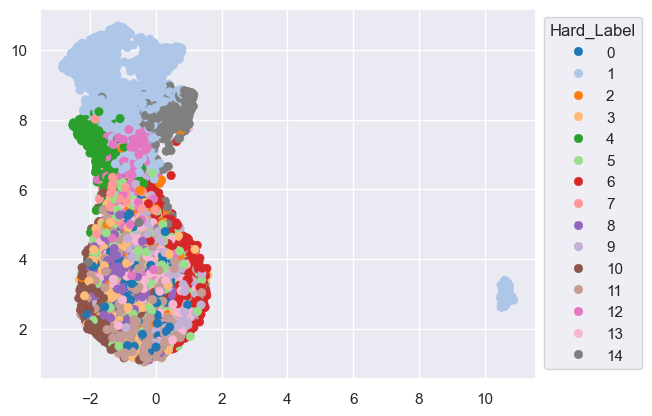

In [70]:
umap_original = umap.UMAP(n_neighbors = 300, random_state = 0).fit_transform(core_customers.drop(columns=['Hard_Label']))
targets = core_customers['Hard_Label']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [71]:
X = core_customers.drop(columns=['Hard_Label']).values

# Computing SST
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

# Computing SSW
ssw_iter = []                   # Outer summation
for i in np.unique(core_customers['Hard_Label']):  # Loop for inner summation
    X_k = X[core_customers['Hard_Label'] == i]     # Data points belonging to cluster k
    inner_sum = np.sum(np.square(X_k - X_k.mean(axis=0)), axis=0)
    ssw_iter.append(inner_sum)
ssw_per_feature = np.sum(ssw_iter, axis=0)  # Outer summation
ssw = np.sum(ssw_per_feature, axis=0)

# Computing SSB
ssb_iter = []
for i in np.unique(core_customers['Hard_Label']):  # Loop for summation
    X_k = X[core_customers['Hard_Label'] == i]     # Data points belonging to cluster k
    ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))

ssb_per_feature = np.sum(ssb_iter, axis=0)
ssb = np.sum(ssb_per_feature, axis=0)

In [72]:
sil_c15 = silhouette_score(X, core_customers['Hard_Label'])

c_row = pd.DataFrame([{
    'num_clusters': len(np.unique(core_customers['Hard_Label'])),
    'ssw (Lower is better, 0 to +∞)': ssw,
    'ssb (Higher is better, 0 to SST)': ssb,
    'silhouette_score (Higher is better, −1 to +1)': sil_c15,
    'r2 (Higher is better, 0 to 1)': ssb / sst,
    'Method': 'C-means'
}])

column_order = [
    'Method',
    'num_clusters',
    'r2 (Higher is better, 0 to 1)',
    'silhouette_score (Higher is better, −1 to +1)',
    'ssw (Lower is better, 0 to +∞)',
    'ssb (Higher is better, 0 to SST)'
]

c_row = c_row[column_order]

display(c_row)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,C-means,15,0.309286,0.06475,166360.934851,74492.631967


## <a id='toc1_13_'></a>[Conclusion](#toc0_)

To conclude about which final clustering perspective we are going to select we will analyse the metrics of our final clusters and also consider the interpretability/profiling of the results.

In [73]:
overall_clustering_results = pd.concat([c_row, km_row, hc_row], ignore_index=True)
display(overall_clustering_results)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,C-means,15,0.309286,0.064750,166360.934851,74492.631967
1,K-Means,14,0.294340,0.064566,175141.594595,73053.697048
2,Hierarchical,18,0.307923,0.064537,171770.312253,76424.979390


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Method</th>
      <th>num_clusters</th>
      <th>r2 (Higher is better, 0 to 1)</th>
      <th>silhouette_score (Higher is better, −1 to +1)</th>
      <th>ssw (Lower is better, 0 to +∞)</th>
      <th>ssb (Higher is better, 0 to SST)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Hierarchical</td>
      <td>15</td>
      <td>0.288842</td>
      <td>0.082880</td>
      <td>176506.061185</td>
      <td>71689.230458</td>
    </tr>
    <tr>
      <th>1</th>
      <td>K-Means</td>
      <td>16</td>
      <td>0.304098</td>
      <td>0.070579</td>
      <td>172719.613920</td>
      <td>75475.677723</td>
    </tr>
  </tbody>
</table>
</div>

After seeing the metrics of this clusters and the ones created without using the autoencoder, we choose to use as final soluton our hierarquical of 18 clusters, because it is the one with better customers profiling (more diverse, unique and meaninfull clusters), also it is the one with better metrics overall (C-means in metrics we can say it has the same performance).

## <a id='toc1_14_'></a>[Final Cluster](#toc0_)

**Profiling Hierarquical with 18 Clusters using an Autoencoder:**

First, we observe that longitude and latitude lose their significance as they remain almost constant across all clusters, while the other variables used to build the clusters vary significantly depending on the group.

Regarding categorical variables, most clusters do not change much; only one or two clusters show behavioral shifts in variables such as Province or State, City, Education, and Marital Status.

Here is the profiling for each cluster:

+ **The October Loyals (956):** Medium income, low revenue, long tenure. They have not purchased recently but remain a consistent, engaged group over the years. These are "October people" who accumulate points year-round to use in October when they fly less but with companions.

+ **The Pandemic Drop-offs (209):** Medium income, low revenue, moderate tenure. These are lost customers who were active in 2019 and 2020 but stopped almost completely in 2021. They previously traveled with consistent frequency and distance each month.

+ **The September Loyals (2706):** Medium income, low revenue, long tenure. Loyal, very engaged customers who purchased recently. "September people" who save points all year to use in September for flights with companions.

+ **The January Average (1045):** Medium income, low revenue, long tenure. Recently active and traveling more now than before (highly engaged). "January people" who use accumulated points for companion travel in January.

+ **The Summer-Fall Hybrids (613):** Medium income, medium revenue, moderate tenure. Recently active and showing increased engagement. "July people" who travel with companions in July and tend to travel alone in autumn.

+ **The May Planners (1078):** Medium income, medium revenue, moderate tenure. Recently active and now very engaged. "May people" who accumulate points to use during May for companion travel.

+ **The Lost Holiday Drifters (565):** Low income, low revenue, short tenure. Lost customers who were never highly engaged; they use points and tend to travel more with companions in December.

+ **The Autumn Budget (178):** Low income, low revenue, short tenure. Recently active and becoming more engaged, specifically during the autumn months.

+ **The June Loyals (897):** Medium income, medium revenue, long tenure. Very engaged, loyal customers. "June people" who save points all year for companion travel in June.

+ **Holiday Travelers (66):** Medium income, low revenue, short tenure. Recently active and increasing engagement. They travel with companions in February and June, using points in most months except November and December (when they travel the most).

+ **The November Loyals (1029):** Medium income, medium revenue, long tenure. Consistent, engaged group. "November people" who redeem points for companion travel in November.

+ **The Dormant Browsers (517):** Low income, low revenue, moderate tenure. Have not purchased recently but show some new engagement; they travel consistently but infrequently across all months and use points.

+ **The March Loyals (1126):** Medium income, medium revenue, long tenure. Consistent, engaged group. "March people" who accumulate points for companion travel in March.

+ **VIPs (64):** High income, high revenue, short tenure. Recently active and engaged. They travel in June with companions and are frequent autumn travelers, using points throughout the year except in Q4. Almost 100% Bachelors, that are Divorced or Married, with the more proportion of mens (~35%).

+ **The Q4 Boomerang (691):** Medium income, low revenue, short tenure. Re-engaged customers who are now moderately active, particularly in autumn and December with companions.

+ **The December Loyals (949):** Medium income, medium revenue, long tenure. Very engaged, loyal customers. "December people" who redeem points for companion travel in December.

+ **The February Loyals (992):** Medium income, low revenue, long tenure. Very engaged, loyal customers. "February people" who save points for companion travel in February.

+ **New travelers (2891):** Medium income, medium revenue, very short tenure (newest). Re-engaged, moderately active customers who use points and travel primarily in autumn.

We will saved the final cluster label of each customer.

In [159]:
hc_final_label.to_csv("hc_final_label.csv", index=True)

And now we will analyse the importance of each feature to do clusters seeing the feature importance on a Desicion tree classifier.

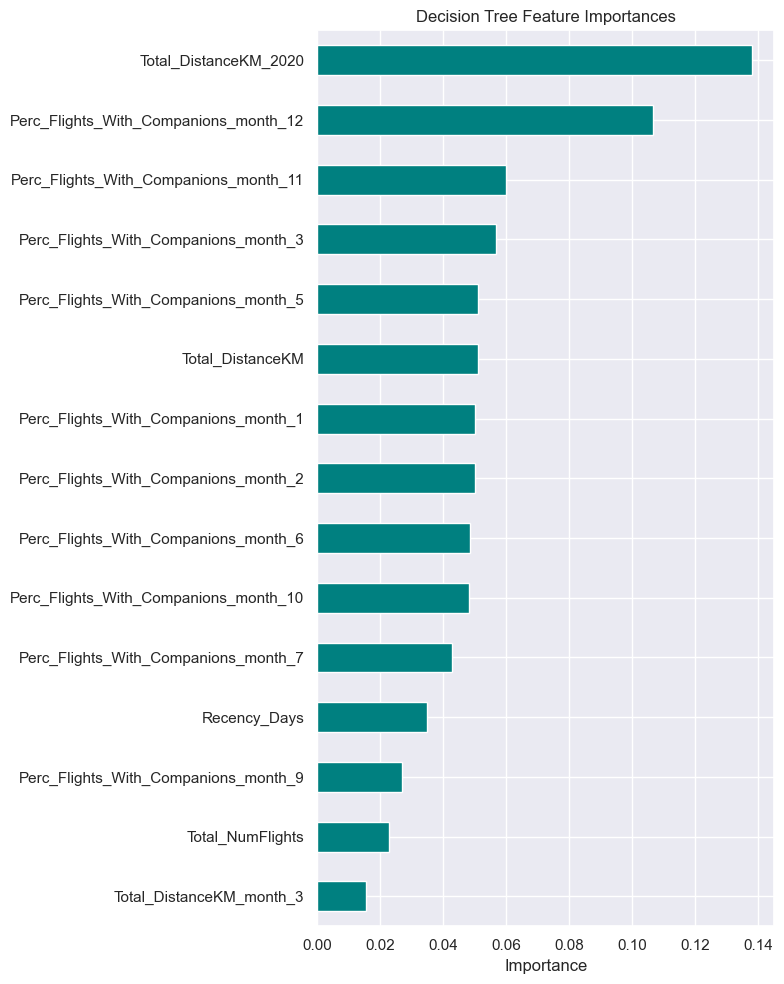

In [157]:
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(umap_for_modeling, hc_final_label)

# Feature importances
importances = pd.Series(dt.feature_importances_, index=umap_for_modeling.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8,10))
importances.tail(15).plot(kind='barh', color='teal')
plt.xlabel('Importance')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()

We concluded that the top 15 features that contributed the most to improve the gini on our model were:
+ Total Distance on 2020 (contribution of 13%).
+ % Flights with companions month 12 (contribution of ~11%).
+ % Flights with companions month 11 (contribution of ~6%).
+ % Flights with companions month 3 (contribution of ~5.5%).
+ % Flights with companions month 5 (contribution of ~5%).
+ Total distance (contribution of ~5%).
+ % Flights with companions month 1 (contribution of ~5%).
+ % Flights with companions month 2 (contribution of ~5%).
+ % Flights with companions month 6 (contribution of ~5%).
+ % Flights with companions month 10 (contribution of ~5%).
+ % Flights with companions month 7 (contribution of ~4.5%).
+ Recency (contribution of ~3.5%).
+ % Flights with companions month 9 (contribution of ~3%).
+ Total NumFlights (contribution of ~2.5%).
+ Total Distance month 3 (contribution of ~1.5%).

In conclusion, we can determine that our clusters are defined by three key dimensions: monthly patterns (seasonal travel), yearly perspectives (long-term loyalty and tenure), and the general behavioral characteristics of the customer, such as recency and engagement levels.